In [3]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
import torch 
import copy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
from src.utils import (
    print_post_norm_stats,
    print_raw_night_stats,
    train_val_test_split_indices
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    train_one_epoch,
    evaluate,
    evaluate_on_test,
    evaluate_csi_and_ghi,
)
from src.plot import(
    plot_full_images_from_loader,
)

from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.utils import crop_back, pad_to_32

from src.model_Twin import(TwinFiLMUNetTiny)

In [3]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_30mins_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [ ]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
)

print("Saved:", out)
print("Final shape:", shape)


Saved: Data/output/combined_hourly_with_elev_landmask_TEST.npz
Final shape: (7941, 12, 50, 50)


In [5]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (23625, 12, 50, 50)
y shape: (23625, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


In [6]:
import numpy as np

def compute_means(arr):
    # arr: (T,H,W) or (T,1,H,W)
    if arr.ndim == 4:
        arr = arr[:, 0]
    return arr.mean(axis=(1,2))

def make_labels(c0, c1, csi,
                tw_cs_thr=76.0,      # W/m^2 : twilight if clear-sky GHI below this
                clear_thr=0.80,      # CSI mean threshold for "clear"
                cloudy_thr=0.35):    # CSI mean threshold for "cloudy"
    """
    Returns labels:
      0=twilight, 1=clear, 2=cloudy, 3=mixed
    """
    c0m  = compute_means(c0)
    c1m  = compute_means(c1)
    csim = compute_means(csi)

    labels = np.full(len(c1m), 3, dtype=np.int64)  # default mixed

    tw = c1m < tw_cs_thr
    labels[tw] = 0

    daytime = ~tw
    labels[daytime & (csim >= clear_thr)] = 1
    labels[daytime & (csim <= cloudy_thr)] = 2

    return labels, {"c0_mean": c0m, "c1_mean": c1m, "csi_mean": csim}


In [7]:
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_train_val_test_split(labels, train=0.7, val=0.15, test=0.15, seed=42):
    idx = np.arange(len(labels))

    idx_train, idx_tmp, y_train, y_tmp = train_test_split(
        idx, labels, test_size=(1-train), random_state=seed, stratify=labels
    )

    val_frac_of_tmp = val / (val + test)
    idx_val, idx_test, _, _ = train_test_split(
        idx_tmp, y_tmp, test_size=(1-val_frac_of_tmp),
        random_state=seed, stratify=y_tmp
    )
    return idx_train, idx_val, idx_test


In [8]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)

In [9]:
c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_train_val_test_split(labels, 0.8, 0.1, 0.1, seed=42)

In [10]:
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

In [11]:
import numpy as np

y = y_train.reshape(-1)

for p in [1,5,50,95,99]:
    print(f"p{p}: {np.percentile(y, p):.4f}")

print("min:", y.min(), "max:", y.max())


p1: 0.0621
p5: 0.1060
p50: 0.8129
p95: 1.0000
p99: 1.0000
min: 0.04862536 max: 1.0


channel_mean: [238.66437  247.30698  254.30418  276.60678  259.0976   278.6026
 277.43613  274.47504  263.09882   39.706436  34.05114    0.3652  ]
channel_std: [ 9.577975   11.47075    12.711327   19.808594   12.378416   20.610844
 20.99358    20.233007   16.079489    0.3124471  80.81088     0.48147944]

In [12]:
# 4) compute per-channel min max on TRAIN only
#    X_train: (T_train, C, H, W)
channel_min = np.nanmin(X_train, axis=(0, 2, 3))   # (C,)
channel_max = np.nanmax(X_train, axis=(0, 2, 3))   # (C,)

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

print("channel_min:", channel_min)
print("channel_max:", channel_max)

np.savez(
    "Data/static/minmax_strat_stats_day_30mins.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)


channel_min: [187.04999 183.7     185.03    182.54    208.92    182.60999 181.82
 182.57999 185.31999  38.89      0.        0.     ]
channel_max: [258.57     268.59     272.9      307.63     279.04     311.07
 309.99     302.66998  281.1       40.579998 804.1716     1.      ]


In [24]:
from torch.utils.data import DataLoader

train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)

batch_size = 64


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [15]:
import kornia
import torch.nn as nn
criterion_reg  = nn.SmoothL1Loss(beta=0.03)  # sharper than 0.05
criterion_ssim = kornia.losses.SSIMLoss(window_size=11, reduction="mean")

def grad_loss(pred, true):
    dx_p = pred[..., :, 1:] - pred[..., :, :-1]
    dy_p = pred[..., 1:, :] - pred[..., :-1, :]
    dx_t = true[..., :, 1:] - true[..., :, :-1]
    dy_t = true[..., 1:, :] - true[..., :-1, :]
    return (dx_p - dx_t).abs().mean() + (dy_p - dy_t).abs().mean()

def lap_loss(pred, true):
    k = pred.new_tensor([[0,1,0],[1,-4,1],[0,1,0]]).reshape(1,1,3,3)
    lp = torch.nn.functional.conv2d(pred, k, padding=1)
    lt = torch.nn.functional.conv2d(true, k, padding=1)
    return (lp - lt).abs().mean()

def combined_loss(y_pred, y_true, w_reg=0.85, w_ssim=0.05, w_grad=0.05, w_lap=0.05):
    return (
        w_reg * criterion_reg(y_pred, y_true)
        + w_ssim * criterion_ssim(y_pred, y_true)
        + w_grad * grad_loss(y_pred, y_true)
        + w_lap * lap_loss(y_pred, y_true)
    )

In [ ]:
! export CUDA_VISIBLE_DEVICES=0 

In [19]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(1)

In [20]:
model = TwinFiLMUNetTiny(feature_size=48).to(device)

In [21]:
# ...existing code...
import os, torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch.cuda.is_available:", torch.cuda.is_available())
print("visible GPU count:", torch.cuda.device_count())

# confirm model parameters device
print("model device:", next(model.parameters()).device)

# show per-GPU memory usage (should be nonzero on only one device)
for i in range(torch.cuda.device_count()):
    used = torch.cuda.memory_allocated(i) / 1024**2
    reserved = torch.cuda.memory_reserved(i) / 1024**2
    print(f"GPU {i}: allocated={used:.1f}MB reserved={reserved:.1f}MB")

# enforce single visible GPU
assert torch.cuda.device_count() == 1, f"Expected 1 visible GPU, got {torch.cuda.device_count()}"
# ...existing code...

CUDA_VISIBLE_DEVICES: None
torch.cuda.is_available: True
visible GPU count: 2
model device: cuda:1
GPU 0: allocated=0.0MB reserved=0.0MB
GPU 1: allocated=1.5MB reserved=2.0MB


AssertionError: Expected 1 visible GPU, got 2

In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

model = TwinFiLMUNetTiny(feature_size=24).to(device)

# -----------------------------
# Optimizer + scheduler
# -----------------------------
total_epochs = 150
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-4,
    steps_per_epoch=len(train_loader),
    epochs=total_epochs,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=5.0,        # initial lr = max_lr/div_factor
    final_div_factor=50.0  # final lr = initial_lr/final_div_factor
)

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(total_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, combined_loss, device, scheduler)
    val_loss   = evaluate(model, val_loader, combined_loss, device)
    print(f"Epoch {epoch+1:03d}/{total_epochs}: loss={train_loss:.6f} | val {val_loss:.4f} | lr {optimizer.param_groups[0]['lr']}")


Epoch 001/150: loss=0.141730 | val 0.1081 | lr 0.0001043724419958641
Epoch 002/150: loss=0.118482 | val 0.1048 | lr 0.00011729858549338441
Epoch 003/150: loss=0.107058 | val 0.0980 | lr 0.0001382132423658298
Epoch 004/150: loss=0.101901 | val 0.1156 | lr 0.00016620193137281849
Epoch 005/150: loss=0.098852 | val 0.0935 | lr 0.0002000408633221171
Epoch 006/150: loss=0.097332 | val 0.1054 | lr 0.0002382504505422227
Epoch 007/150: loss=0.095333 | val 0.0907 | lr 0.000279160000995077
Epoch 008/150: loss=0.092198 | val 0.0859 | lr 0.0003209807683163602
Epoch 009/150: loss=0.091796 | val 0.0944 | lr 0.00036188416371272397
Epoch 010/150: loss=0.090875 | val 0.0845 | lr 0.00040008170994612326
Epoch 011/150: loss=0.090532 | val 0.1821 | lr 0.0004339032414636594


In [ ]:
b = next(iter(train_loader))
print(type(b))
if isinstance(b, (list, tuple)):
    print("len:", len(b), "types:", [type(x) for x in b])
elif isinstance(b, dict):
    print("keys:", b.keys())


<class 'list'>
len: 2 types: [<class 'torch.Tensor'>, <class 'torch.Tensor'>]


In [25]:
# usage
metrics = evaluate_on_test(model, test_loader, device)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

RMSE: 0.113492
rRMSE: 0.161874
R2: 0.867896
MBE: 0.001639
MAE: 0.069650
mean_true: 0.701113


In [ ]:
no twillight included sigmoid 
RMSE: 0.130254
rRMSE: 0.183818
R2: 0.819233
MBE: -0.001009
MAE: 0.083949
mean_true: 0.708604

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

In [26]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)

ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)


swin
{'CSI_RMSE': 0.1379673331975937,
 'CSI_rRMSE': 0.19519218802452087,
 'CSI_R2': 0.7941124439239502,
 'CSI_MBE': 0.01562388613820076,
 'CSI_MAE': 0.08873958885669708,
 'CSI_mean_true': 0.7068281769752502,
 'GHI_RMSE': 78.64848327636719,
 'GHI_rRMSE': 0.1939978450536728,
 'GHI_R2': 0.9189393520355225,
 'GHI_MBE': 13.343442916870117,
 'GHI_MAE': 46.85791015625,
 'GHI_mean_true': 405.4090576171875}

In [39]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


CSI_RMSE: 0.113492
CSI_rRMSE: 0.161874
CSI_R2: 0.867896
CSI_MBE: 0.001639
CSI_MAE: 0.069650
CSI_mean_true: 0.701113
GHI_RMSE: 15.273839
GHI_rRMSE: 0.150331
GHI_R2: 0.951417
GHI_MBE: 0.815047
GHI_MAE: 8.970662
GHI_mean_true: 101.601112


In [47]:
15.273839*4

61.095356

CSI_RMSE: 0.133899
CSI_rRMSE: 0.189436
CSI_R2: 0.806077
CSI_MBE: 0.008085
CSI_MAE: 0.086178
CSI_mean_true: 0.706828
GHI_RMSE: 76.838295
GHI_rRMSE: 0.189533
GHI_R2: 0.922628
GHI_MBE: 8.518705
GHI_MAE: 45.806358
GHI_mean_true: 405.409058

In [ ]:
# ckpt_path = "Model_checkpoint/ckpt_last2.pt"

# torch.save({
#     "epoch": epoch,                      # current epoch index (0-based)
#     "model": model.state_dict(),
#     "optimizer": optimizer.state_dict(),
#     "scheduler": scheduler.state_dict() if scheduler is not None else None,
# }, ckpt_path)


In [13]:
PATH = "Model_checkpoint/Swin+_elevation_no_twil_30mins.pth"
# torch.save(model.state_dict(), PATH)

In [22]:
import torch
import torch.nn.functional as F


model = TwinFiLMUNetTiny(feature_size=48).to(device)
# 1) load checkpoint
model.load_state_dict(torch.load(PATH))
model.to(device)


TwinFiLMUNetTiny(
  (enc_atmos): Sequential(
    (0): Conv2d(9, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
    (3): ResBlockGN(
      (c1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n1): GroupNorm(8, 48, eps=1e-05, affine=True)
      (c2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n2): GroupNorm(8, 48, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
  )
  (enc_geo): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
  )
  (film): FiLM(
    (gamma): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
    (beta): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
  )
  (down): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), paddi

In [81]:
print("y_pred shape:", y_pred.shape)
print("CSI predcit: min", y_pred.min(), "max", y_pred.max(), "mean", y_pred.mean())

y_pred shape: (795, 1, 50, 50)
CSI predcit: min 0.049597565 max 1.0518675 mean 0.7149137


In [25]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=40,
    seed=5
)

NameError: name 'ghi_cs_test' is not defined

In [27]:
import numpy as np
import torch
import torch.nn.functional as F

def _grad_mag_np(y):  # y: (N,1,H,W)
    # simple finite diff, padded back
    dx = y[..., :, 1:] - y[..., :, :-1]
    dy = y[..., 1:, :] - y[..., :-1, :]
    dx = np.pad(dx, ((0,0),(0,0),(0,0),(0,1)), mode="constant")
    dy = np.pad(dy, ((0,0),(0,0),(0,1),(0,0)), mode="constant")
    return np.sqrt(dx*dx + dy*dy + 1e-12)

@torch.no_grad()
def analyze_error_regions(model, loader, device,
                          y_sat=0.98,          # define "saturated near 1"
                          y_mid=0.95,          # non-sat threshold
                          edge_quantile=0.90,  # top 10% gradient pixels => edges
                          top_k=50):
    """
    Returns:
      report: dict with dataset-level breakdown and per-sample metrics
      worst_idxs: indices of worst samples by RMSE
    """
    model.eval()
    y_true_list, y_pred_list = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device).contiguous()
        xb_pad, h, w = pad_to_32(xb)

        y_hat = model(xb_pad)
        y_hat = crop_back(y_hat, h, w).contiguous()

        # If model outputs logits, uncomment:
        # y_hat = torch.sigmoid(y_hat)

        y_true_list.append(yb.cpu().numpy())
        y_pred_list.append(y_hat.cpu().numpy())

    y_true = np.concatenate(y_true_list, axis=0).astype(np.float64)  # (N,1,H,W)
    y_pred = np.concatenate(y_pred_list, axis=0).astype(np.float64)

    N = y_true.shape[0]
    err = y_pred - y_true
    se  = err**2
    ae  = np.abs(err)

    # per-sample metrics
    rmse_i = np.sqrt(np.mean(se, axis=(1,2,3)))
    mae_i  = np.mean(ae, axis=(1,2,3))
    mbe_i  = np.mean(err, axis=(1,2,3))

    # region masks
    sat_mask = (y_true >= y_sat)              # near 1
    mid_mask = (y_true < y_mid)               # non-saturated (cloud/transition)
    gmag = _grad_mag_np(y_true)               # (N,1,H,W)

    # edge threshold per-sample (robust): top-q gradients within each sample
    edge_mask = np.zeros_like(sat_mask, dtype=bool)
    for i in range(N):
        thr = np.quantile(gmag[i,0].reshape(-1), edge_quantile)
        edge_mask[i,0] = gmag[i,0] >= thr

    # SSE contributions (what drives RMSE)
    total_sse = se.sum()
    sse_sat   = se[sat_mask].sum()
    sse_mid   = se[mid_mask].sum()
    sse_edge  = se[edge_mask].sum()

    # also useful: pixel fractions
    frac_sat  = sat_mask.mean()
    frac_mid  = mid_mask.mean()
    frac_edge = edge_mask.mean()

    # per-sample breakdown (share of SSE inside each region)
    # add epsilon to avoid /0
    eps = 1e-12
    sse_i = se.sum(axis=(1,2,3)) + eps

    def share(mask):
        # mask: (N,1,H,W)
        return (se * mask).sum(axis=(1,2,3)) / sse_i

    share_sat_i  = share(sat_mask)
    share_mid_i  = share(mid_mask)
    share_edge_i = share(edge_mask)

    worst_idxs = np.argsort(rmse_i)[::-1][:min(top_k, N)]

    report = {
        "dataset": {
            "N": int(N),
            "rmse_mean": float(rmse_i.mean()),
            "rmse_p50": float(np.percentile(rmse_i, 50)),
            "rmse_p90": float(np.percentile(rmse_i, 90)),
            "rmse_p99": float(np.percentile(rmse_i, 99)),
            "frac_sat_pixels": float(frac_sat),
            "frac_mid_pixels": float(frac_mid),
            "frac_edge_pixels": float(frac_edge),
            "sse_share_sat": float(sse_sat / (total_sse + eps)),
            "sse_share_mid": float(sse_mid / (total_sse + eps)),
            "sse_share_edge": float(sse_edge / (total_sse + eps)),
        },
        "per_sample": {
            "rmse": rmse_i,
            "mae": mae_i,
            "mbe": mbe_i,
            "sse_share_sat": share_sat_i,
            "sse_share_mid": share_mid_i,
            "sse_share_edge": share_edge_i,
        }
    }
    return report, worst_idxs


In [30]:
report, worst_idxs = analyze_error_regions(model, test_loader, device, top_k=50)

print(report["dataset"])
print("worst_idxs:", worst_idxs[:10])


{'N': 2363, 'rmse_mean': 0.09397943835953353, 'rmse_p50': 0.08339418410930016, 'rmse_p90': 0.17081204661263494, 'rmse_p99': 0.31080828546552974, 'frac_sat_pixels': 0.32111993228946256, 'frac_mid_pixels': 0.6443788404570461, 'frac_edge_pixels': 0.10952382564536606, 'sse_share_sat': 0.05639125345688869, 'sse_share_mid': 0.9277099680688253, 'sse_share_edge': 0.1686862843144095}
worst_idxs: [ 398 1827 1960    1  389  721 1969  528 1570  941]


In [ ]:
rmse_mean = 0.0940
rmse_p50 = 0.0834
rmse_p90 = 0.1708
rmse_p99 = 0.3108

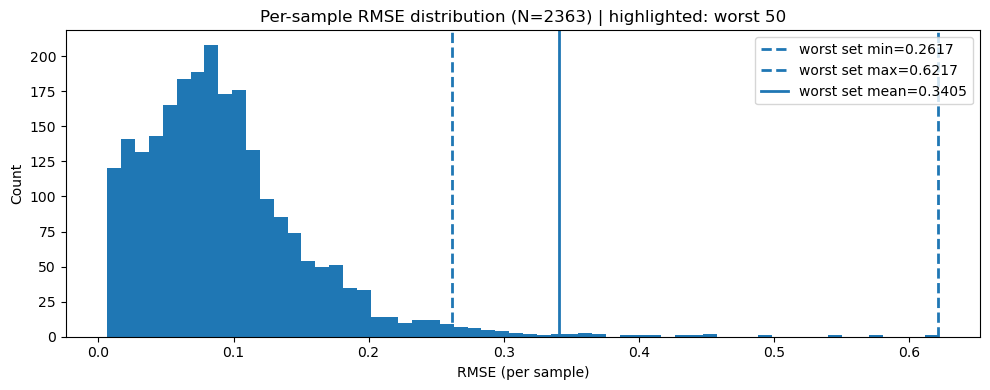

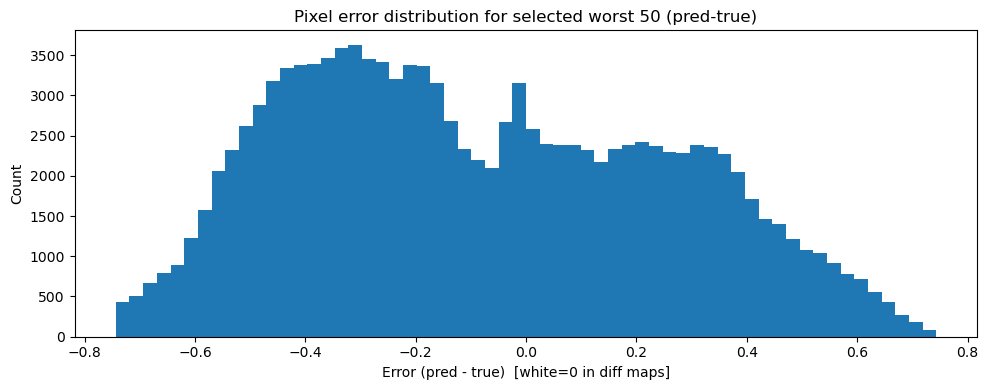

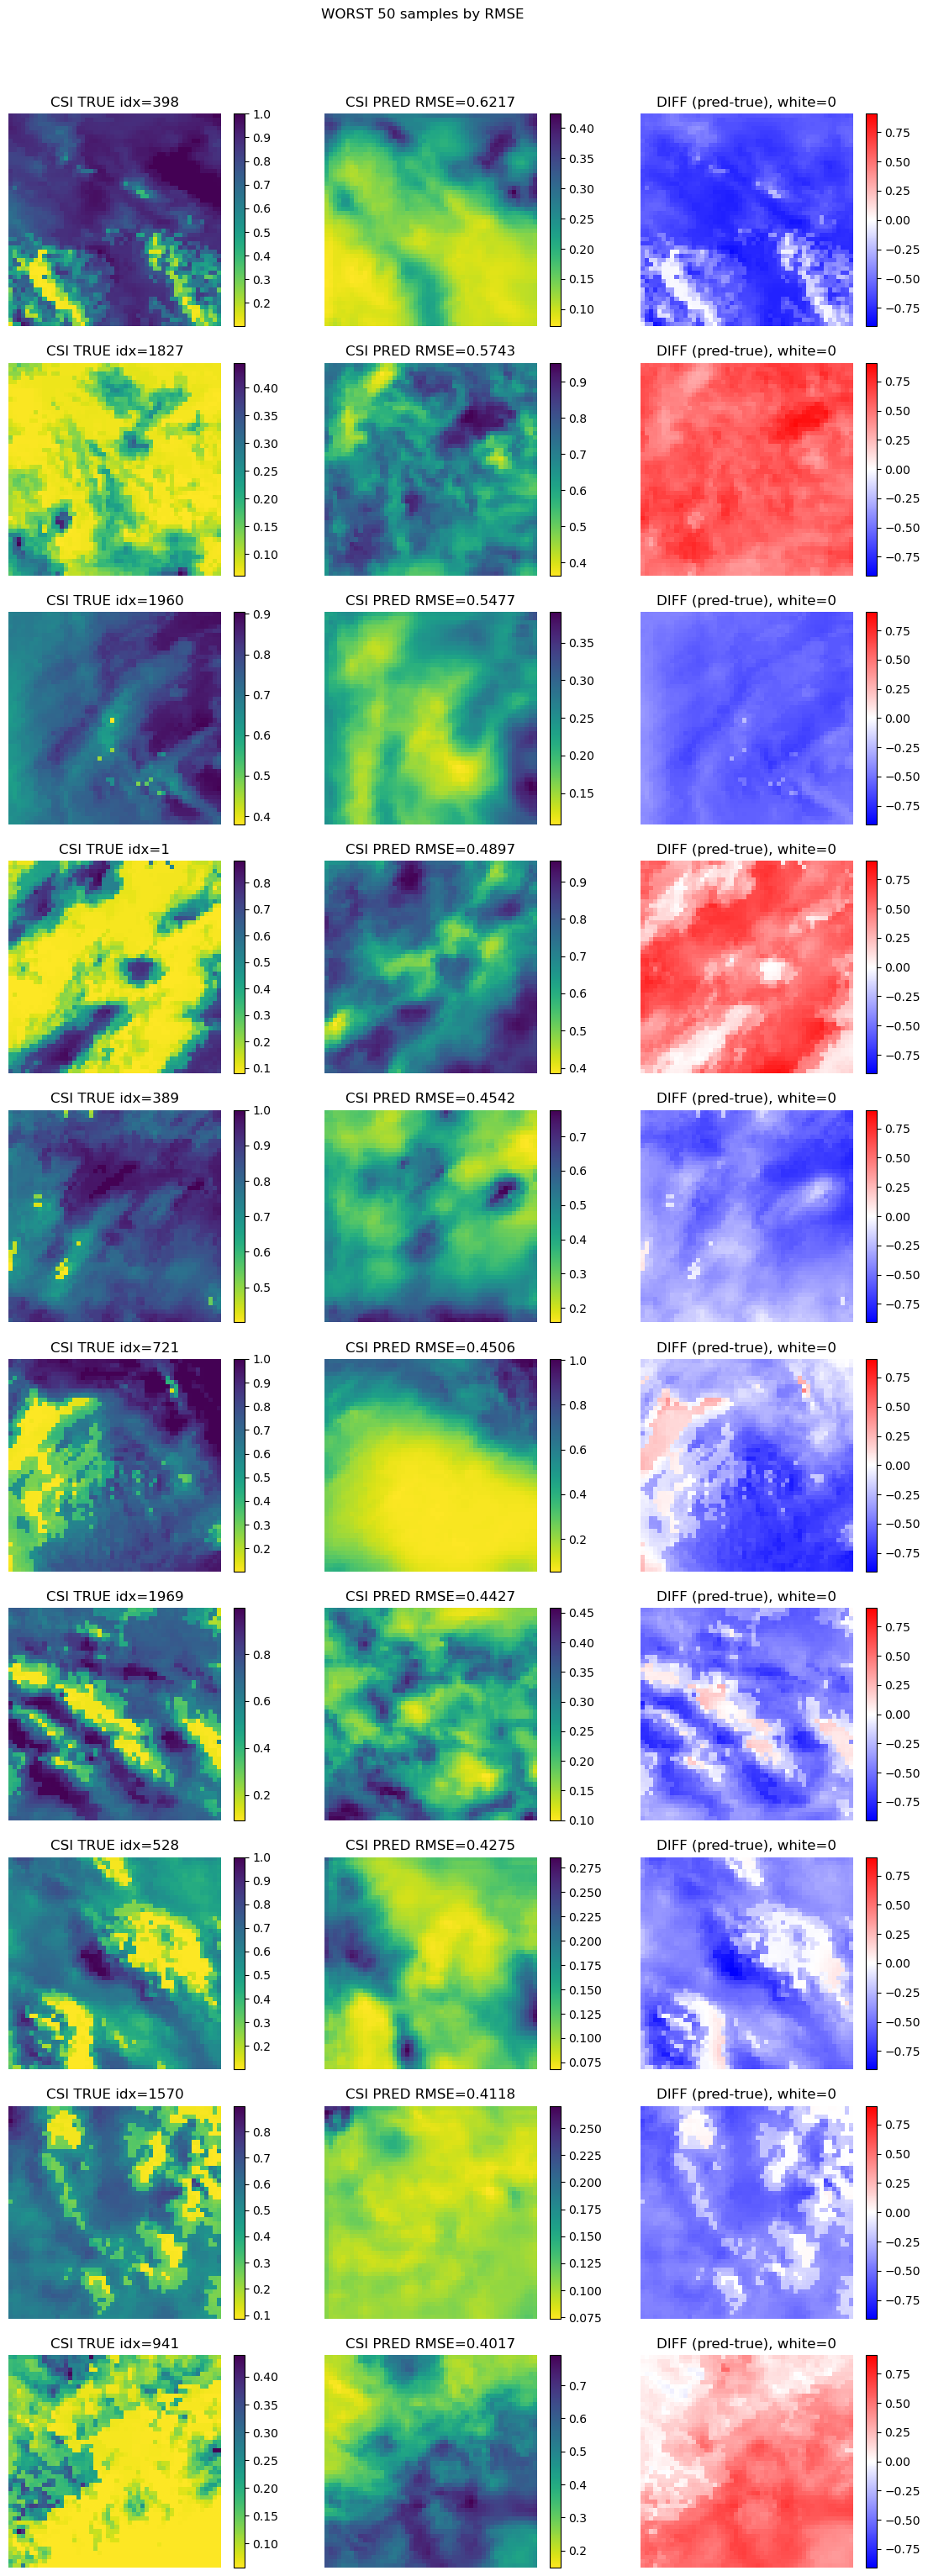

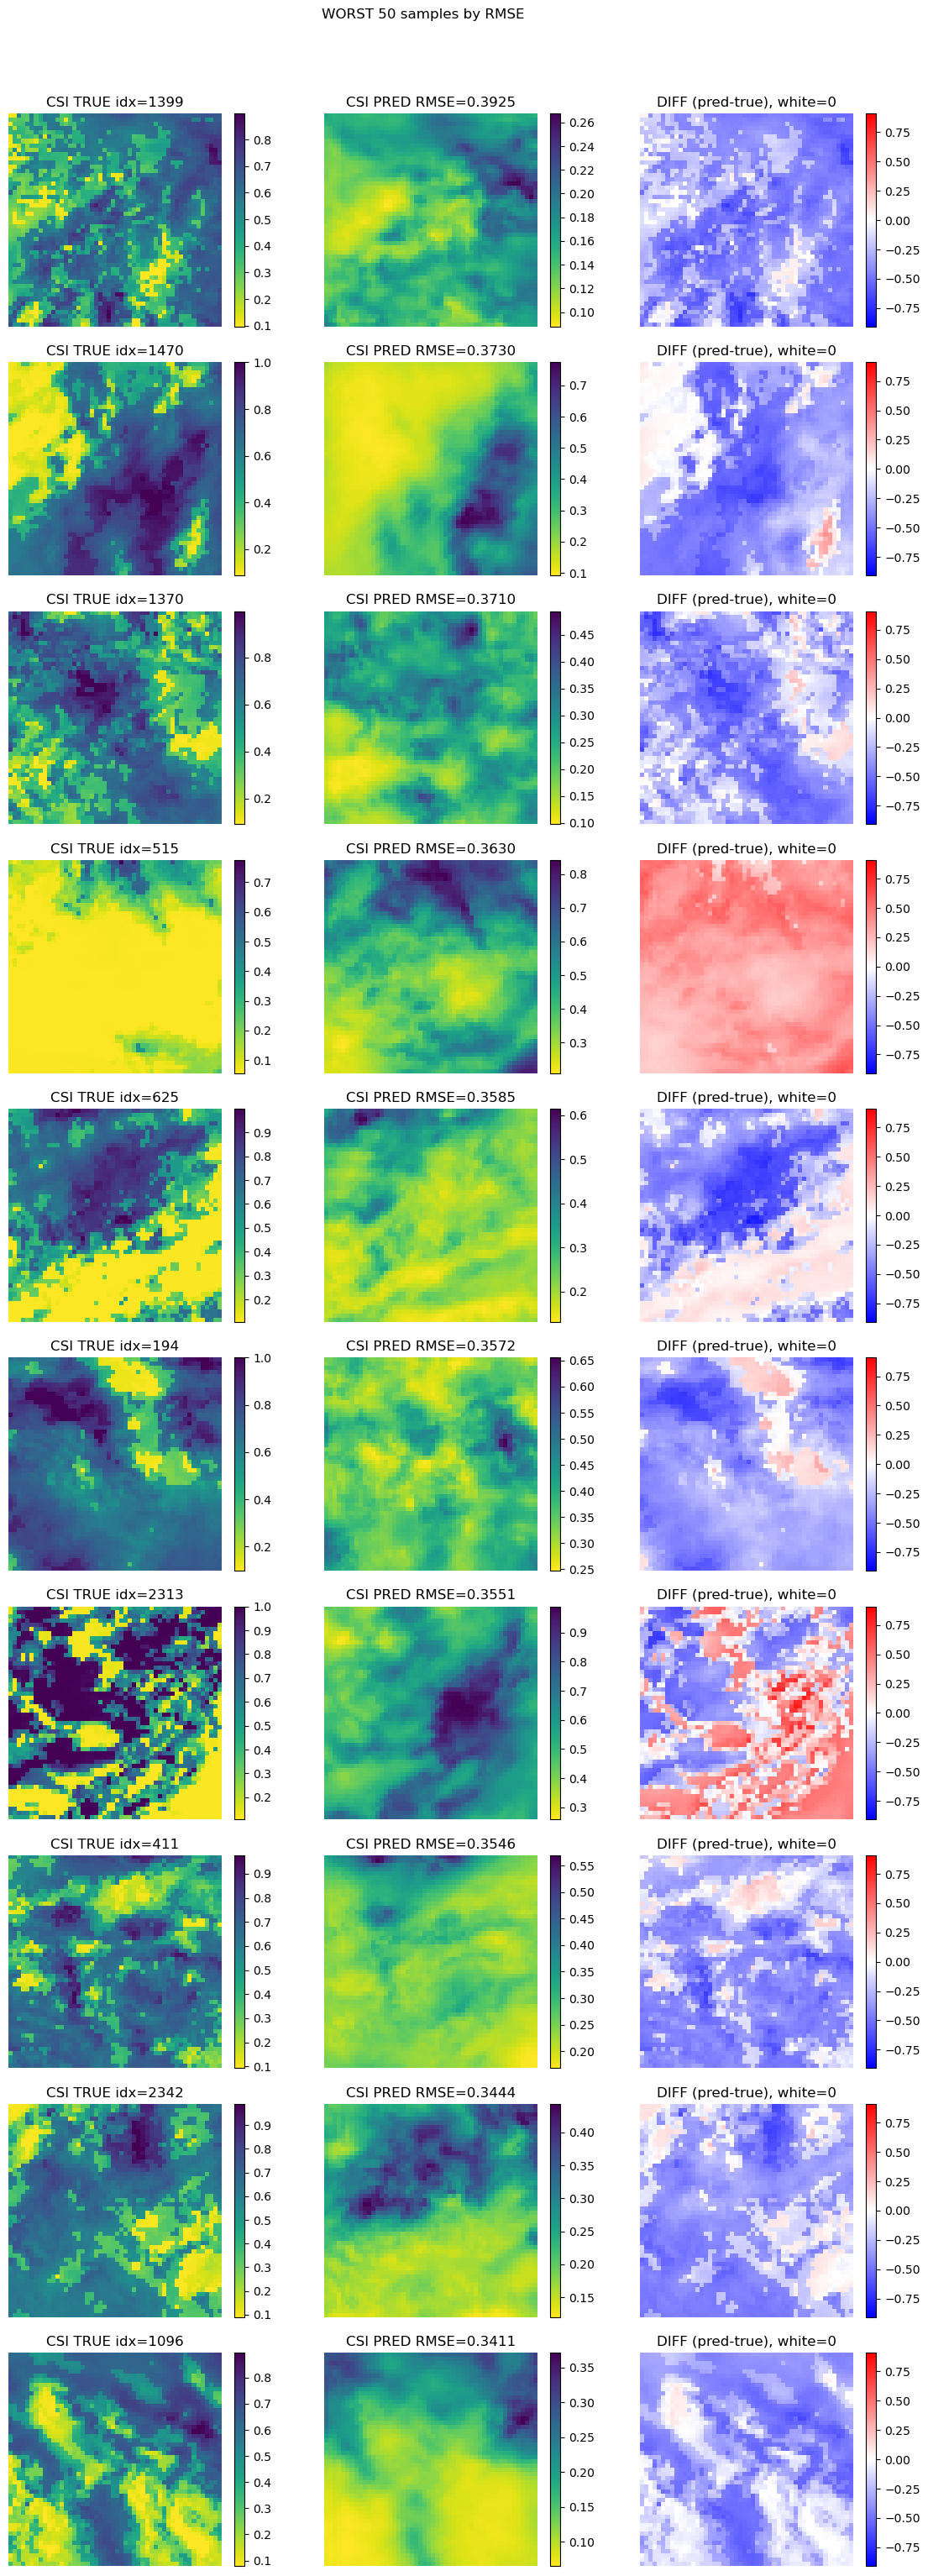

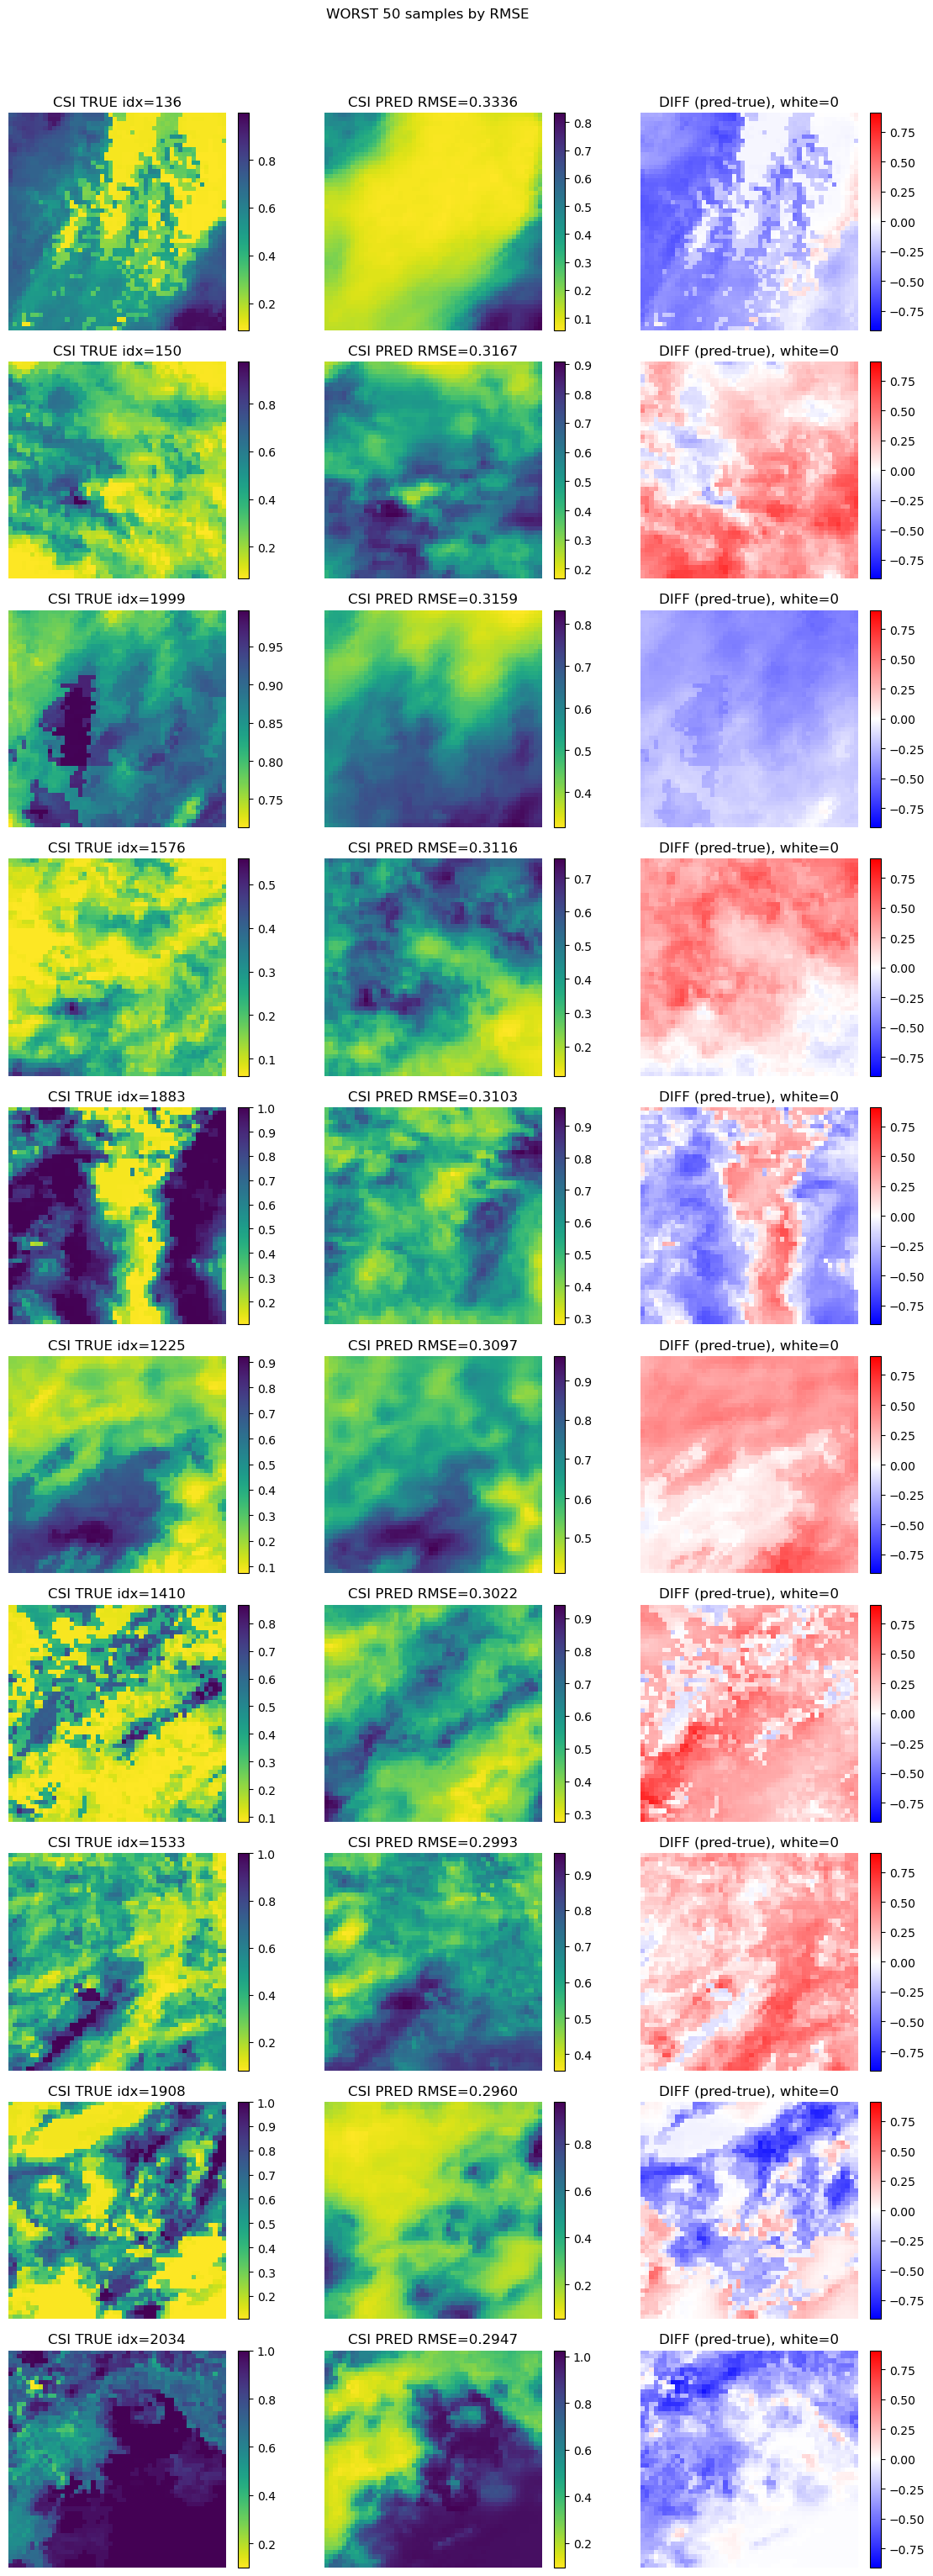

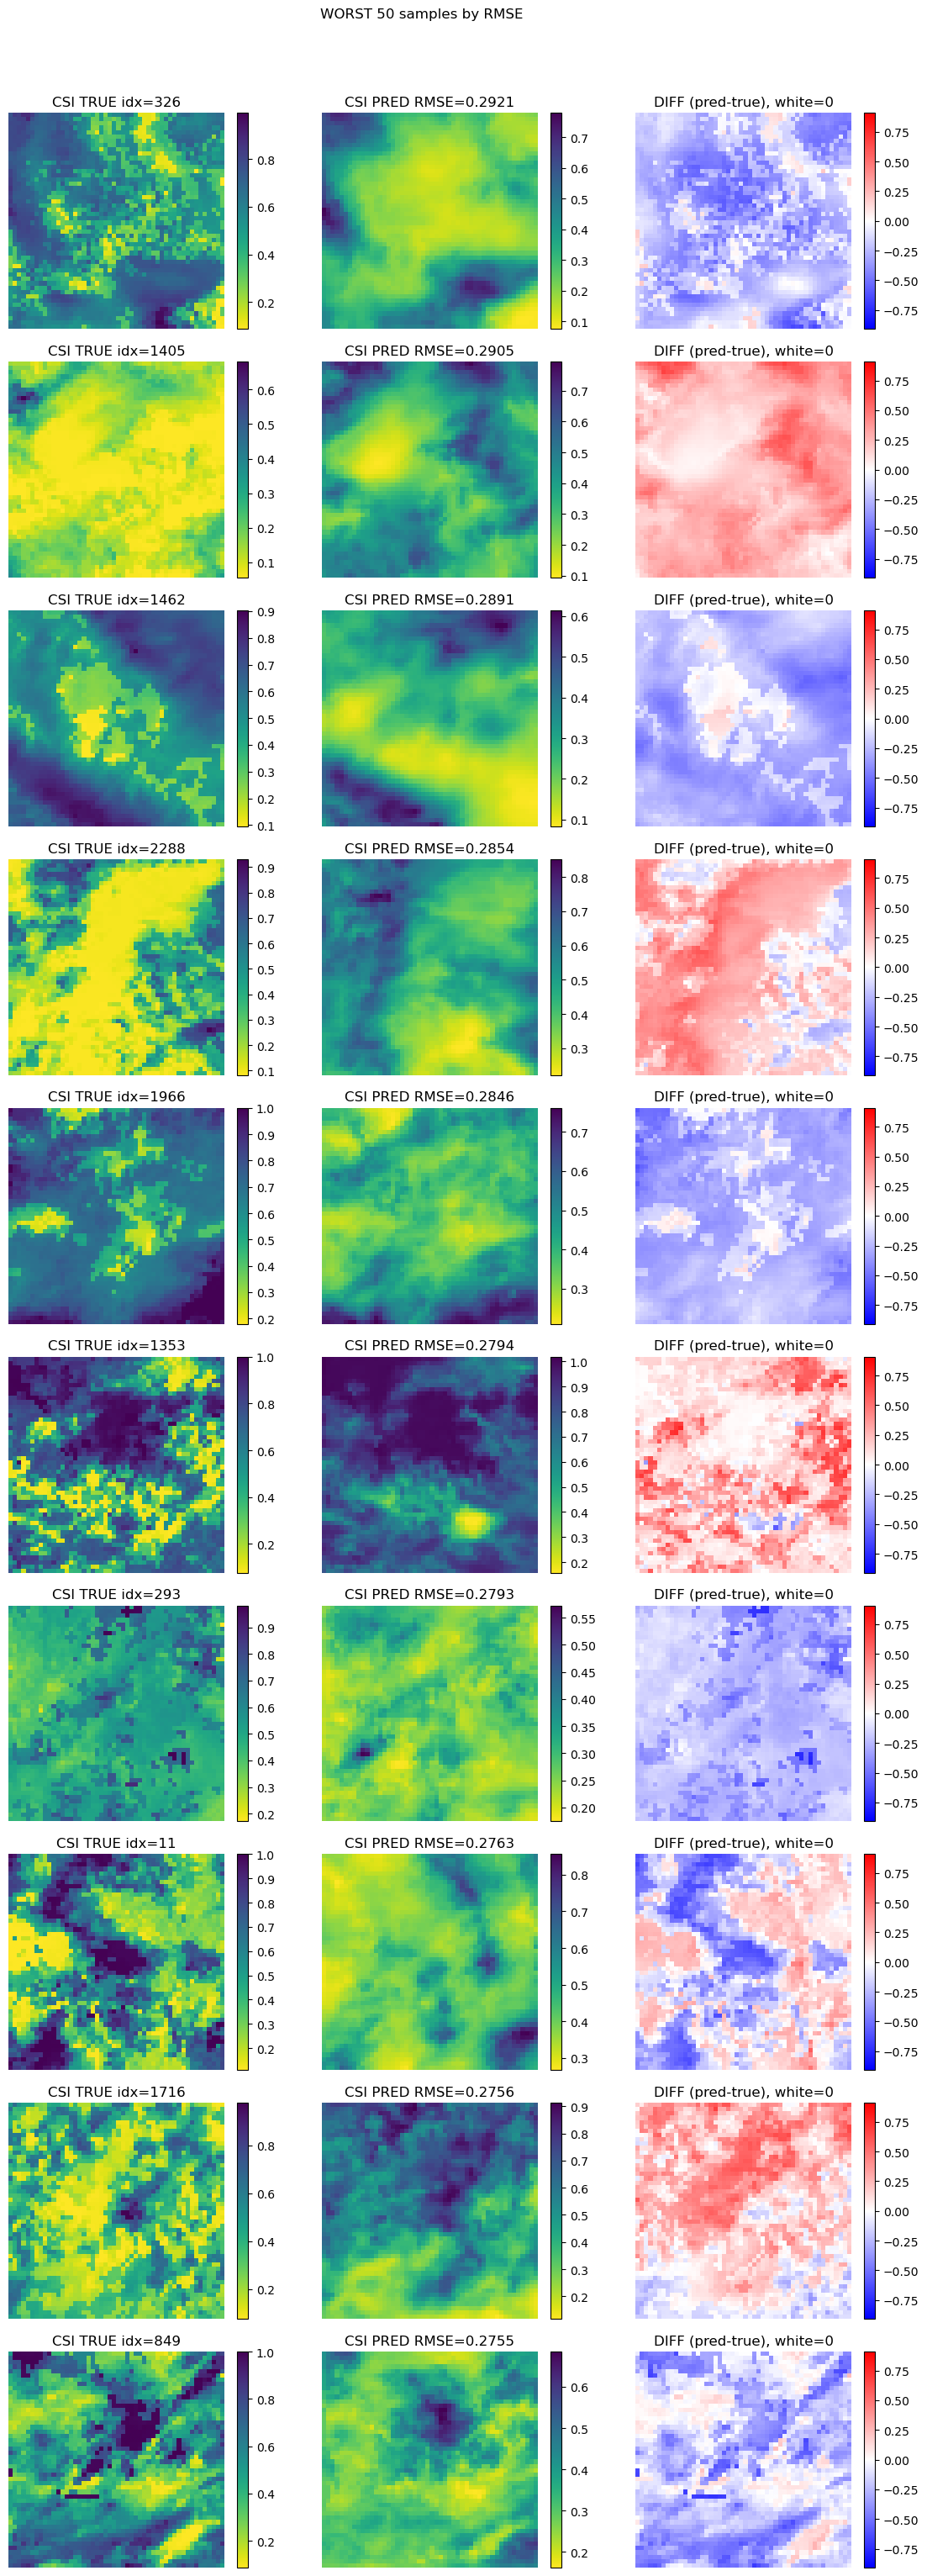

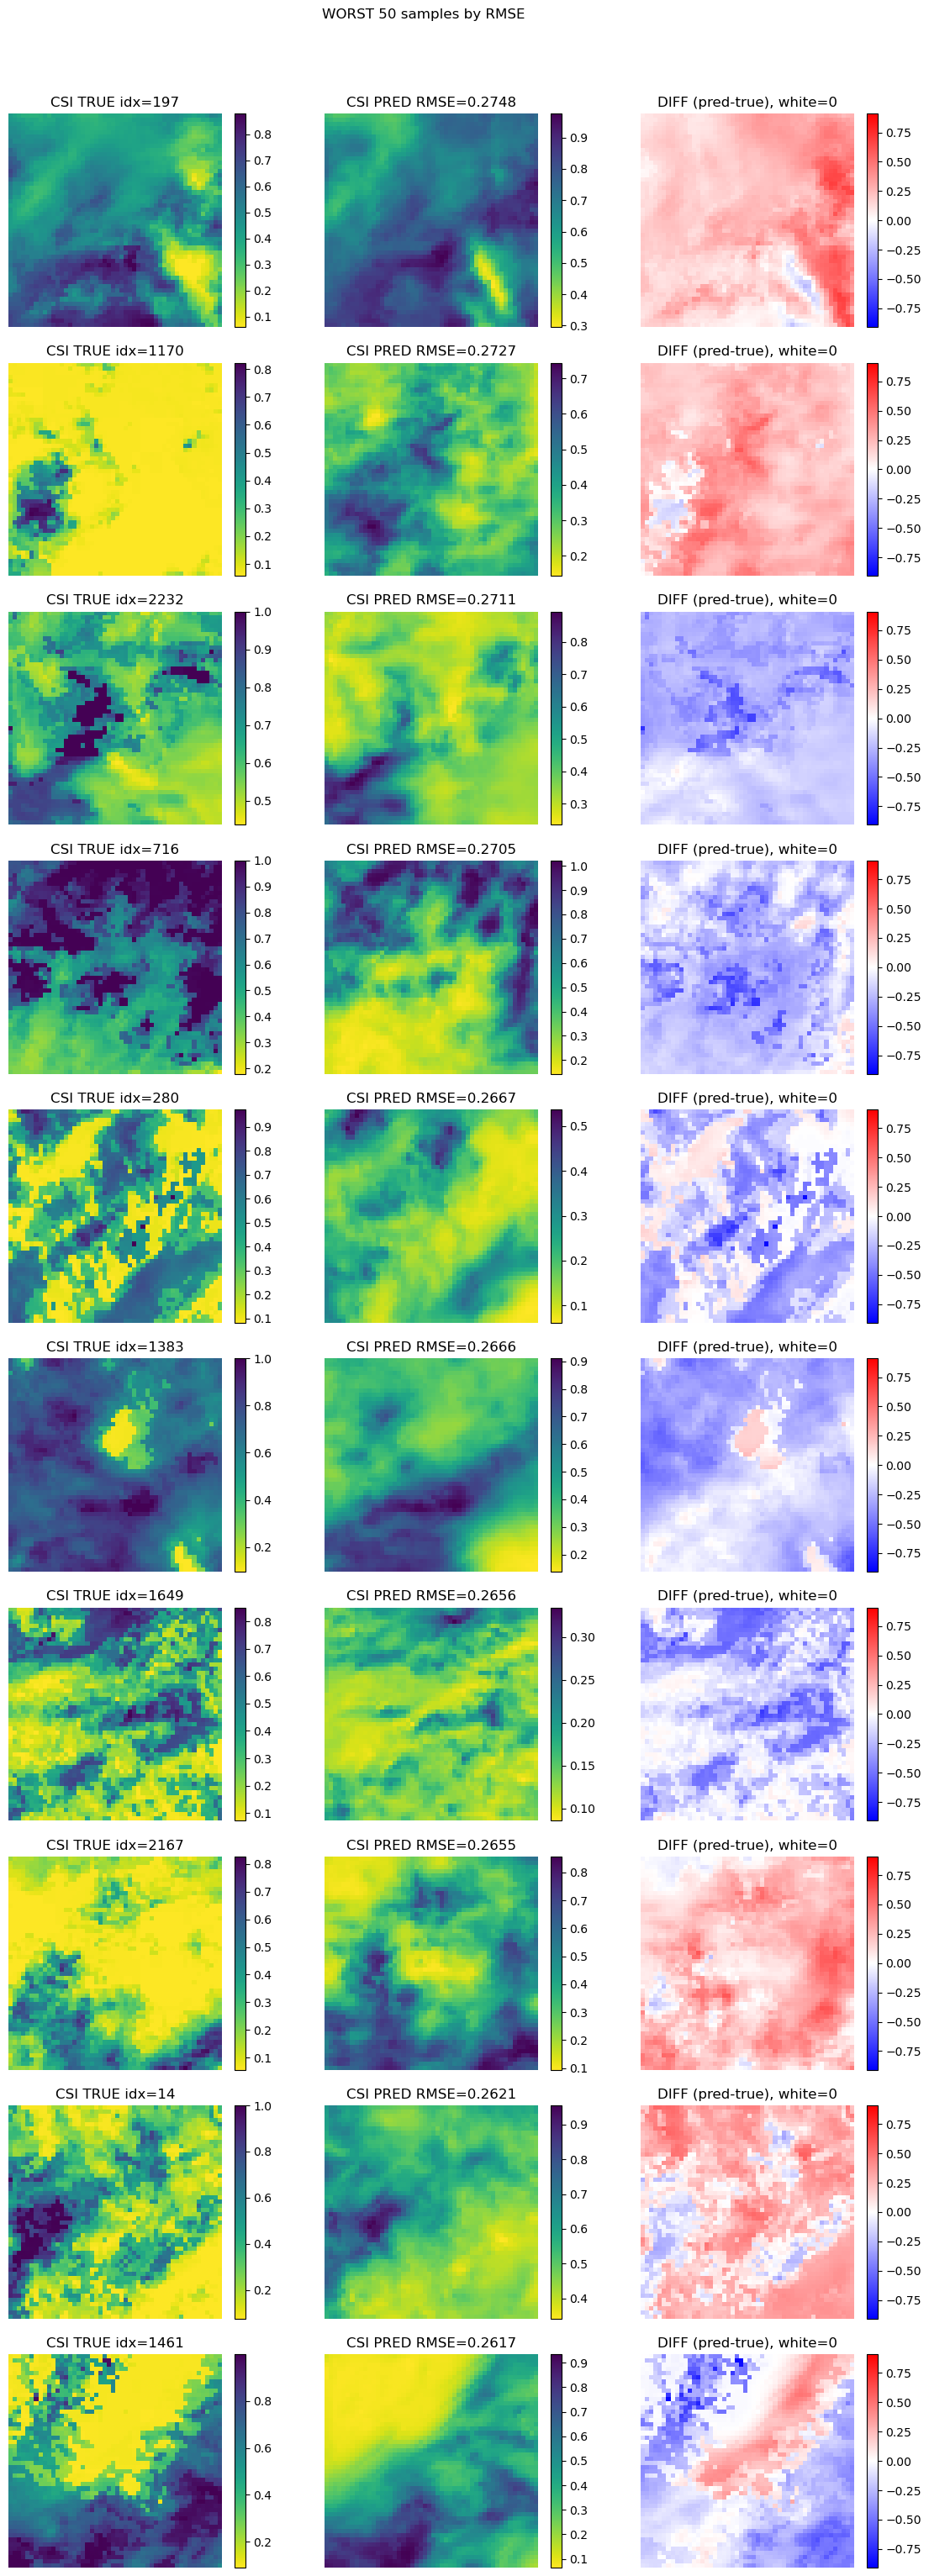

In [31]:
from src.plot import plot_rmse_extremes_with_distribution
worst_idxs, rmse_i = plot_rmse_extremes_with_distribution(
    model, test_loader, device,
    k=50, mode="worst",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True
)


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test,              # (N_test,1,H,W) or (N_test,H,W)
    time_mins, idx_test,      # time_mins: (T,), idx_test: (N_test,)
    k=50, mode="worst", per_fig=10,
    bins=60, show_pixel_error_hist=True,
    use_global_diff_scale=True,
    show_utc=False,           # True: title shows UTC + HKT
):
    """
    Select best/worst K by per-sample CSI RMSE.
    Plot per sample: CSI TRUE, CSI PRED, CSI DIFF(white=0), GHI TRUE, GHI PRED.
    Title shows time in HKT (UTC+8), no idx.

    Assumes time_mins is Unix-epoch minutes in UTC (minutes since 1970-01-01 00:00 UTC).
    """

    assert mode in ("worst", "best")

    # ---- time for test samples (unix minutes UTC) ----
    idx_test = np.asarray(idx_test)
    time_mins = np.asarray(time_mins)
    time_test_mins_utc = time_mins[idx_test]  # (N_test,)

    # ---- ensure ghi_cs_test shape ----
    ghi_cs = np.asarray(ghi_cs_test)
    if ghi_cs.ndim == 3:  # (N,H,W) -> (N,1,H,W)
        ghi_cs = ghi_cs[:, None, :, :]

    model.eval()
    csi_true_list, csi_pred_list = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device).contiguous()

            xb_pad, h, w = pad_to_32(xb)
            y_hat = model(xb_pad)
            y_hat = crop_back(y_hat, h, w).contiguous()

            # If your model outputs logits, uncomment:
            # y_hat = torch.sigmoid(y_hat)

            csi_true_list.append(yb.cpu().numpy())
            csi_pred_list.append(y_hat.cpu().numpy())

    csi_true = np.concatenate(csi_true_list, axis=0).astype(np.float64)  # (N,1,H,W)
    csi_pred = np.concatenate(csi_pred_list, axis=0).astype(np.float64)  # (N,1,H,W)

    N = csi_true.shape[0]
    if ghi_cs.shape[0] != N:
        raise ValueError(
            f"ghi_cs_test N mismatch: {ghi_cs.shape[0]} vs {N}. "
            f"Make sure test_loader order matches ghi_cs_test and shuffle=False."
        )
    if len(time_test_mins_utc) != N:
        raise ValueError(
            f"time_test_mins length {len(time_test_mins_utc)} != {N}. "
            f"Make sure idx_test corresponds to the same test set/order."
        )

    # ---- per-sample RMSE over CSI ----
    err = csi_pred - csi_true
    rmse_i = np.sqrt(np.mean(err**2, axis=(1,2,3)))

    order = np.argsort(rmse_i)  # ascending
    sel = order[:min(k, N)] if mode == "best" else order[::-1][:min(k, N)]

    # ---- RMSE distribution plot ----
    plt.figure(figsize=(10, 4))
    plt.hist(rmse_i, bins=bins)
    s = rmse_i[sel]
    plt.axvline(s.min(), linestyle="--", linewidth=2, label=f"{mode} min={s.min():.4f}")
    plt.axvline(s.max(), linestyle="--", linewidth=2, label=f"{mode} max={s.max():.4f}")
    plt.axvline(s.mean(), linestyle="-",  linewidth=2, label=f"{mode} mean={s.mean():.4f}")
    plt.title(f"CSI per-sample RMSE distribution | highlighted: {mode} {len(sel)}")
    plt.xlabel("RMSE (CSI)")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- optional: pixel error distribution for selected ----
    if show_pixel_error_hist:
        ep = err[sel].reshape(-1)
        lo, hi = np.percentile(ep, [0.5, 99.5])
        m = max(abs(lo), abs(hi))
        plt.figure(figsize=(10, 4))
        plt.hist(ep, bins=bins, range=(-m, m))
        plt.title(f"Pixel error distribution | selected {mode} {len(sel)} (CSI pred-true)")
        plt.xlabel("Error (CSI pred - true)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    # ---- diff colormap scaling (white=0) ----
    global_vmax = (np.max(np.abs(err[sel])) + 1e-12) if use_global_diff_scale else None

    # ---- time label helper: Unix minutes UTC -> HKT ----
    def time_label_hkt(unix_minutes_utc: float) -> str:
        import datetime as dt
        utc_dt = dt.datetime(1970, 1, 1, 0, 0, 0, tzinfo=dt.timezone.utc) + dt.timedelta(minutes=float(unix_minutes_utc))
        hkt = dt.timezone(dt.timedelta(hours=8))
        hkt_dt = utc_dt.astimezone(hkt)
        if show_utc:
            return utc_dt.strftime("%Y-%m-%d %H:%M UTC") + "\n" + hkt_dt.strftime("%Y-%m-%d %H:%M HKT")
        return hkt_dt.strftime("%Y-%m-%d %H:%M HKT")

    # ---- plot samples in batches ----
    for start in range(0, len(sel), per_fig):
        end = min(start + per_fig, len(sel))
        batch = sel[start:end]
        n_rows = len(batch)
        n_cols = 5  # CSI true/pred/diff + GHI true/pred

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
        if n_rows == 1:
            axes = np.expand_dims(axes, axis=0)

        for r, i in enumerate(batch):
            tstr = time_label_hkt(time_test_mins_utc[i])

            # CSI TRUE
            im0 = axes[r,0].imshow(csi_true[i,0], cmap="viridis_r")
            axes[r,0].set_title(f"CSI TRUE\n{tstr}")
            axes[r,0].axis("off")
            fig.colorbar(im0, ax=axes[r,0], fraction=0.046, pad=0.04)

            # CSI PRED
            im1 = axes[r,1].imshow(csi_pred[i,0], cmap="viridis_r")
            axes[r,1].set_title(f"CSI PRED\nRMSE={rmse_i[i]:.4f}\n{tstr}")
            axes[r,1].axis("off")
            fig.colorbar(im1, ax=axes[r,1], fraction=0.046, pad=0.04)

            # CSI DIFF (white=0)
            di = err[i,0]
            vmax = global_vmax if global_vmax is not None else (np.max(np.abs(di)) + 1e-12)
            im2 = axes[r,2].imshow(di, cmap="bwr", vmin=-vmax, vmax=vmax)
            axes[r,2].set_title(f"CSI DIFF (pred-true)\nwhite=0\n{tstr}")
            axes[r,2].axis("off")
            fig.colorbar(im2, ax=axes[r,2], fraction=0.046, pad=0.04)

            # GHI TRUE / PRED
            ghi_true = csi_true[i] * ghi_cs[i]  # (1,H,W)
            ghi_pred = csi_pred[i] * ghi_cs[i]

            im3 = axes[r,3].imshow(ghi_true[0], cmap="inferno")
            axes[r,3].set_title(f"GHI TRUE\n{tstr}")
            axes[r,3].axis("off")
            fig.colorbar(im3, ax=axes[r,3], fraction=0.046, pad=0.04)

            im4 = axes[r,4].imshow(ghi_pred[0], cmap="inferno")
            axes[r,4].set_title(f"GHI PRED\n{tstr}")
            axes[r,4].axis("off")
            fig.colorbar(im4, ax=axes[r,4], fraction=0.046, pad=0.04)

        plt.suptitle(f"{mode.upper()} {len(sel)} samples by CSI RMSE (HKT time + GHI)", y=1.02)
        plt.tight_layout()
        plt.show()

    return sel, rmse_i


In [34]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_no_twillight.npz")
cams_data = cams["data"] # shape (T, 2, H, W)
time_mins = cams["time_min"] 

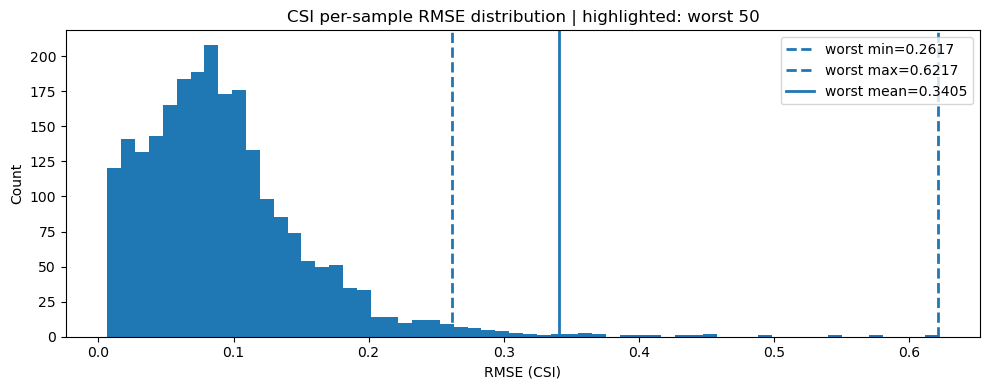

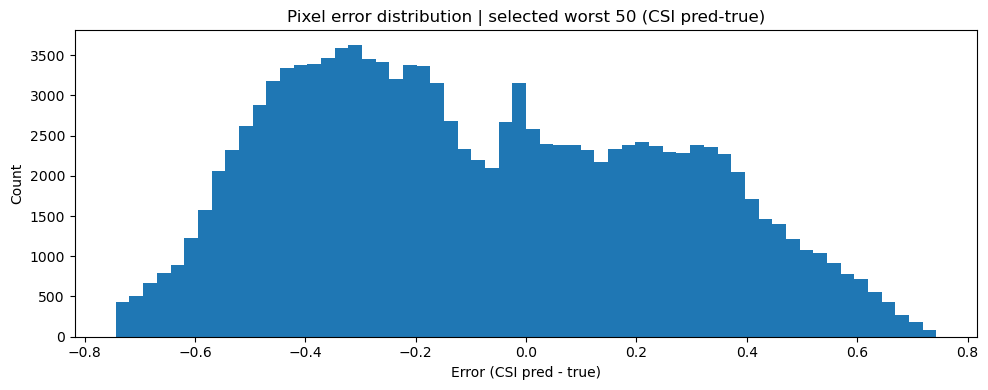

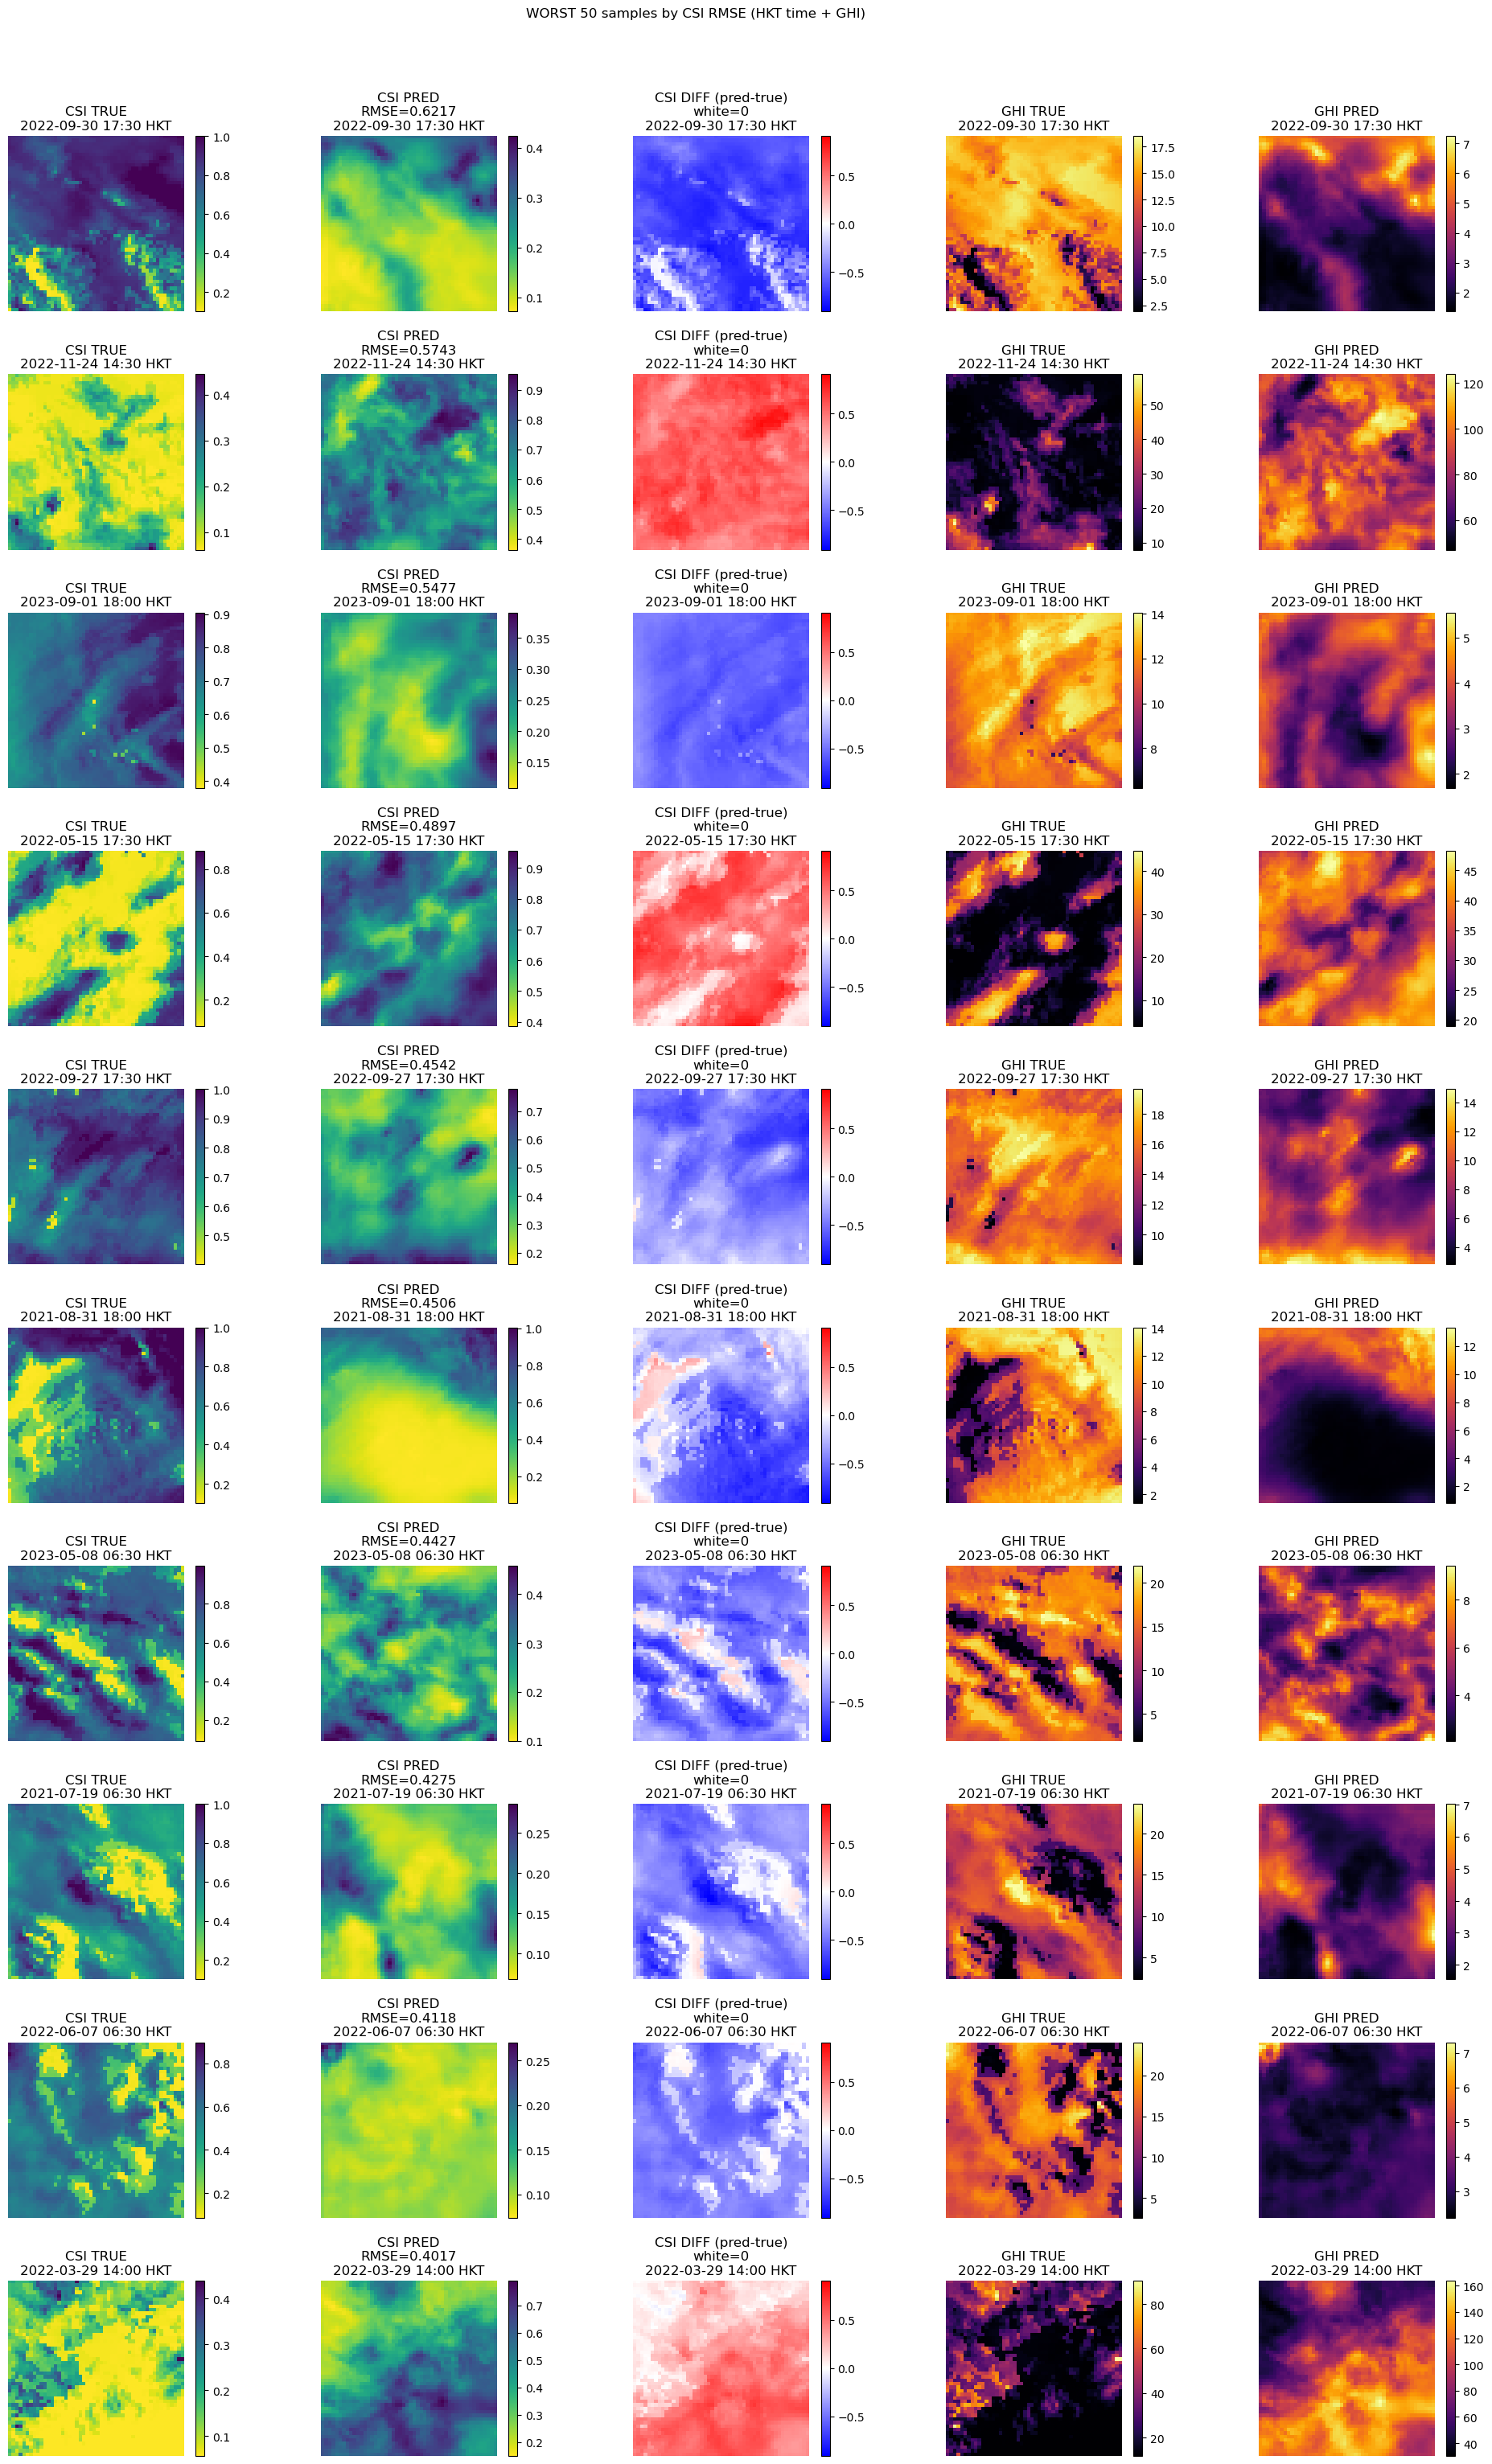

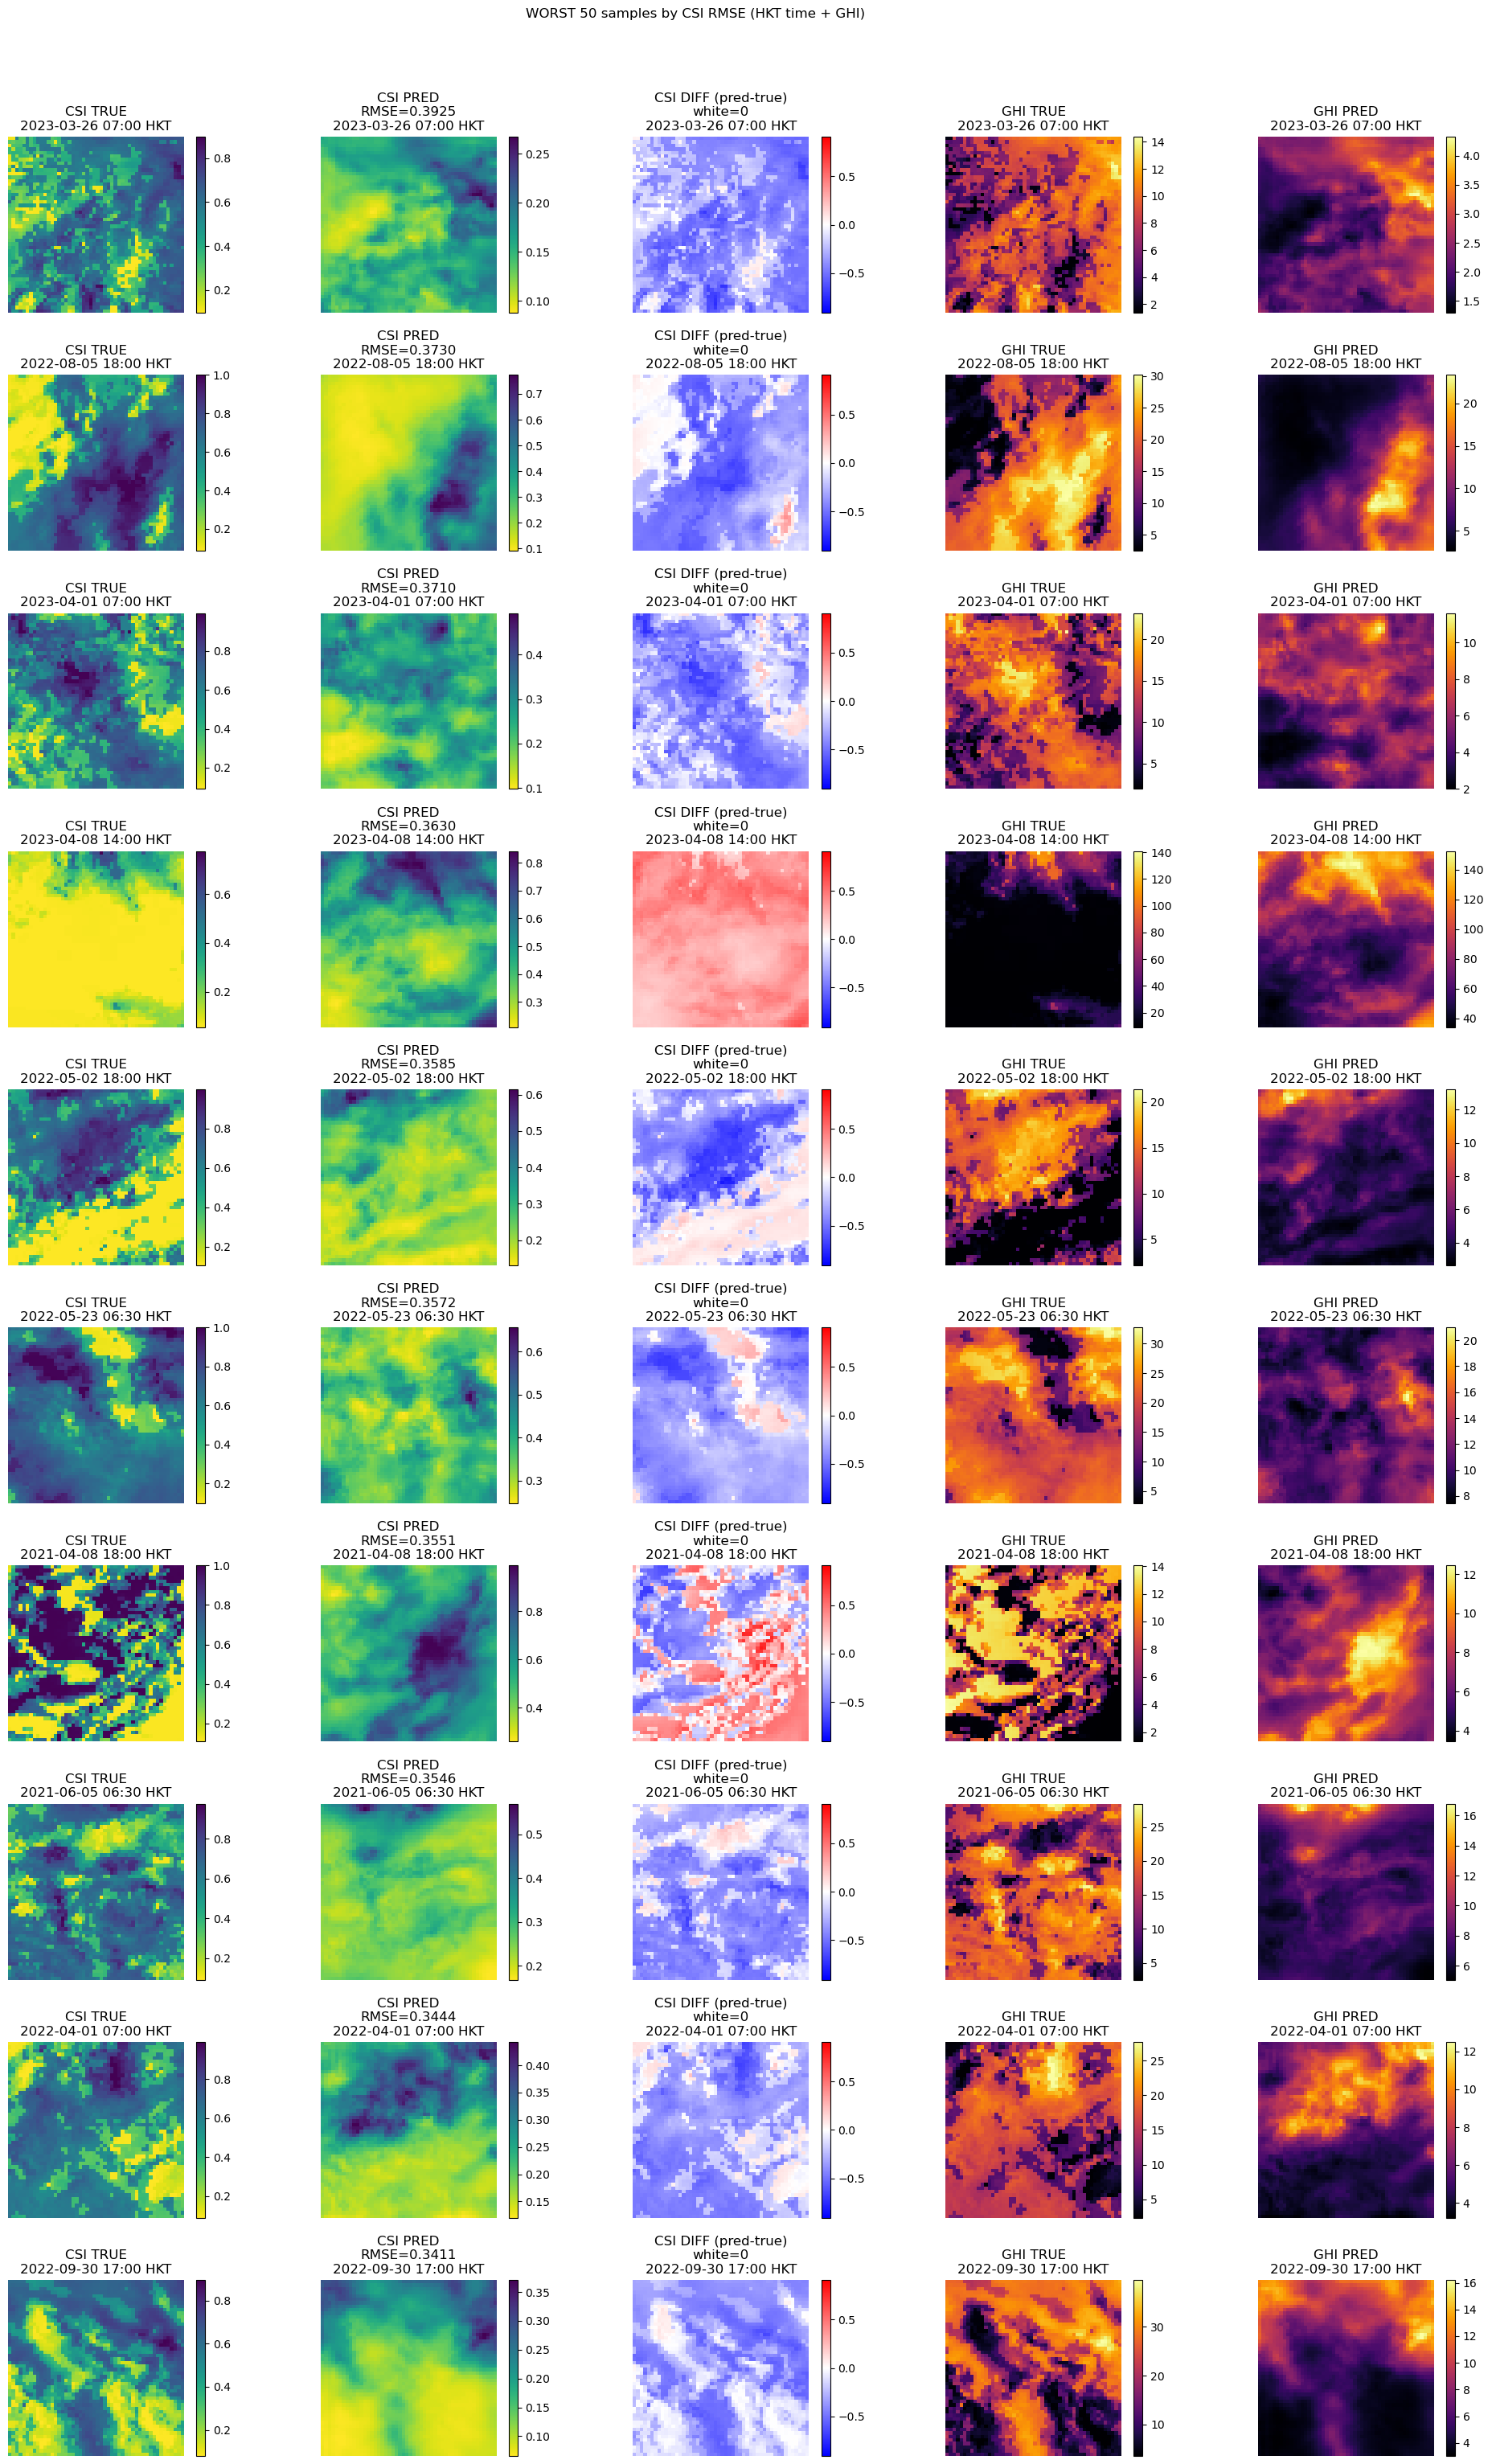

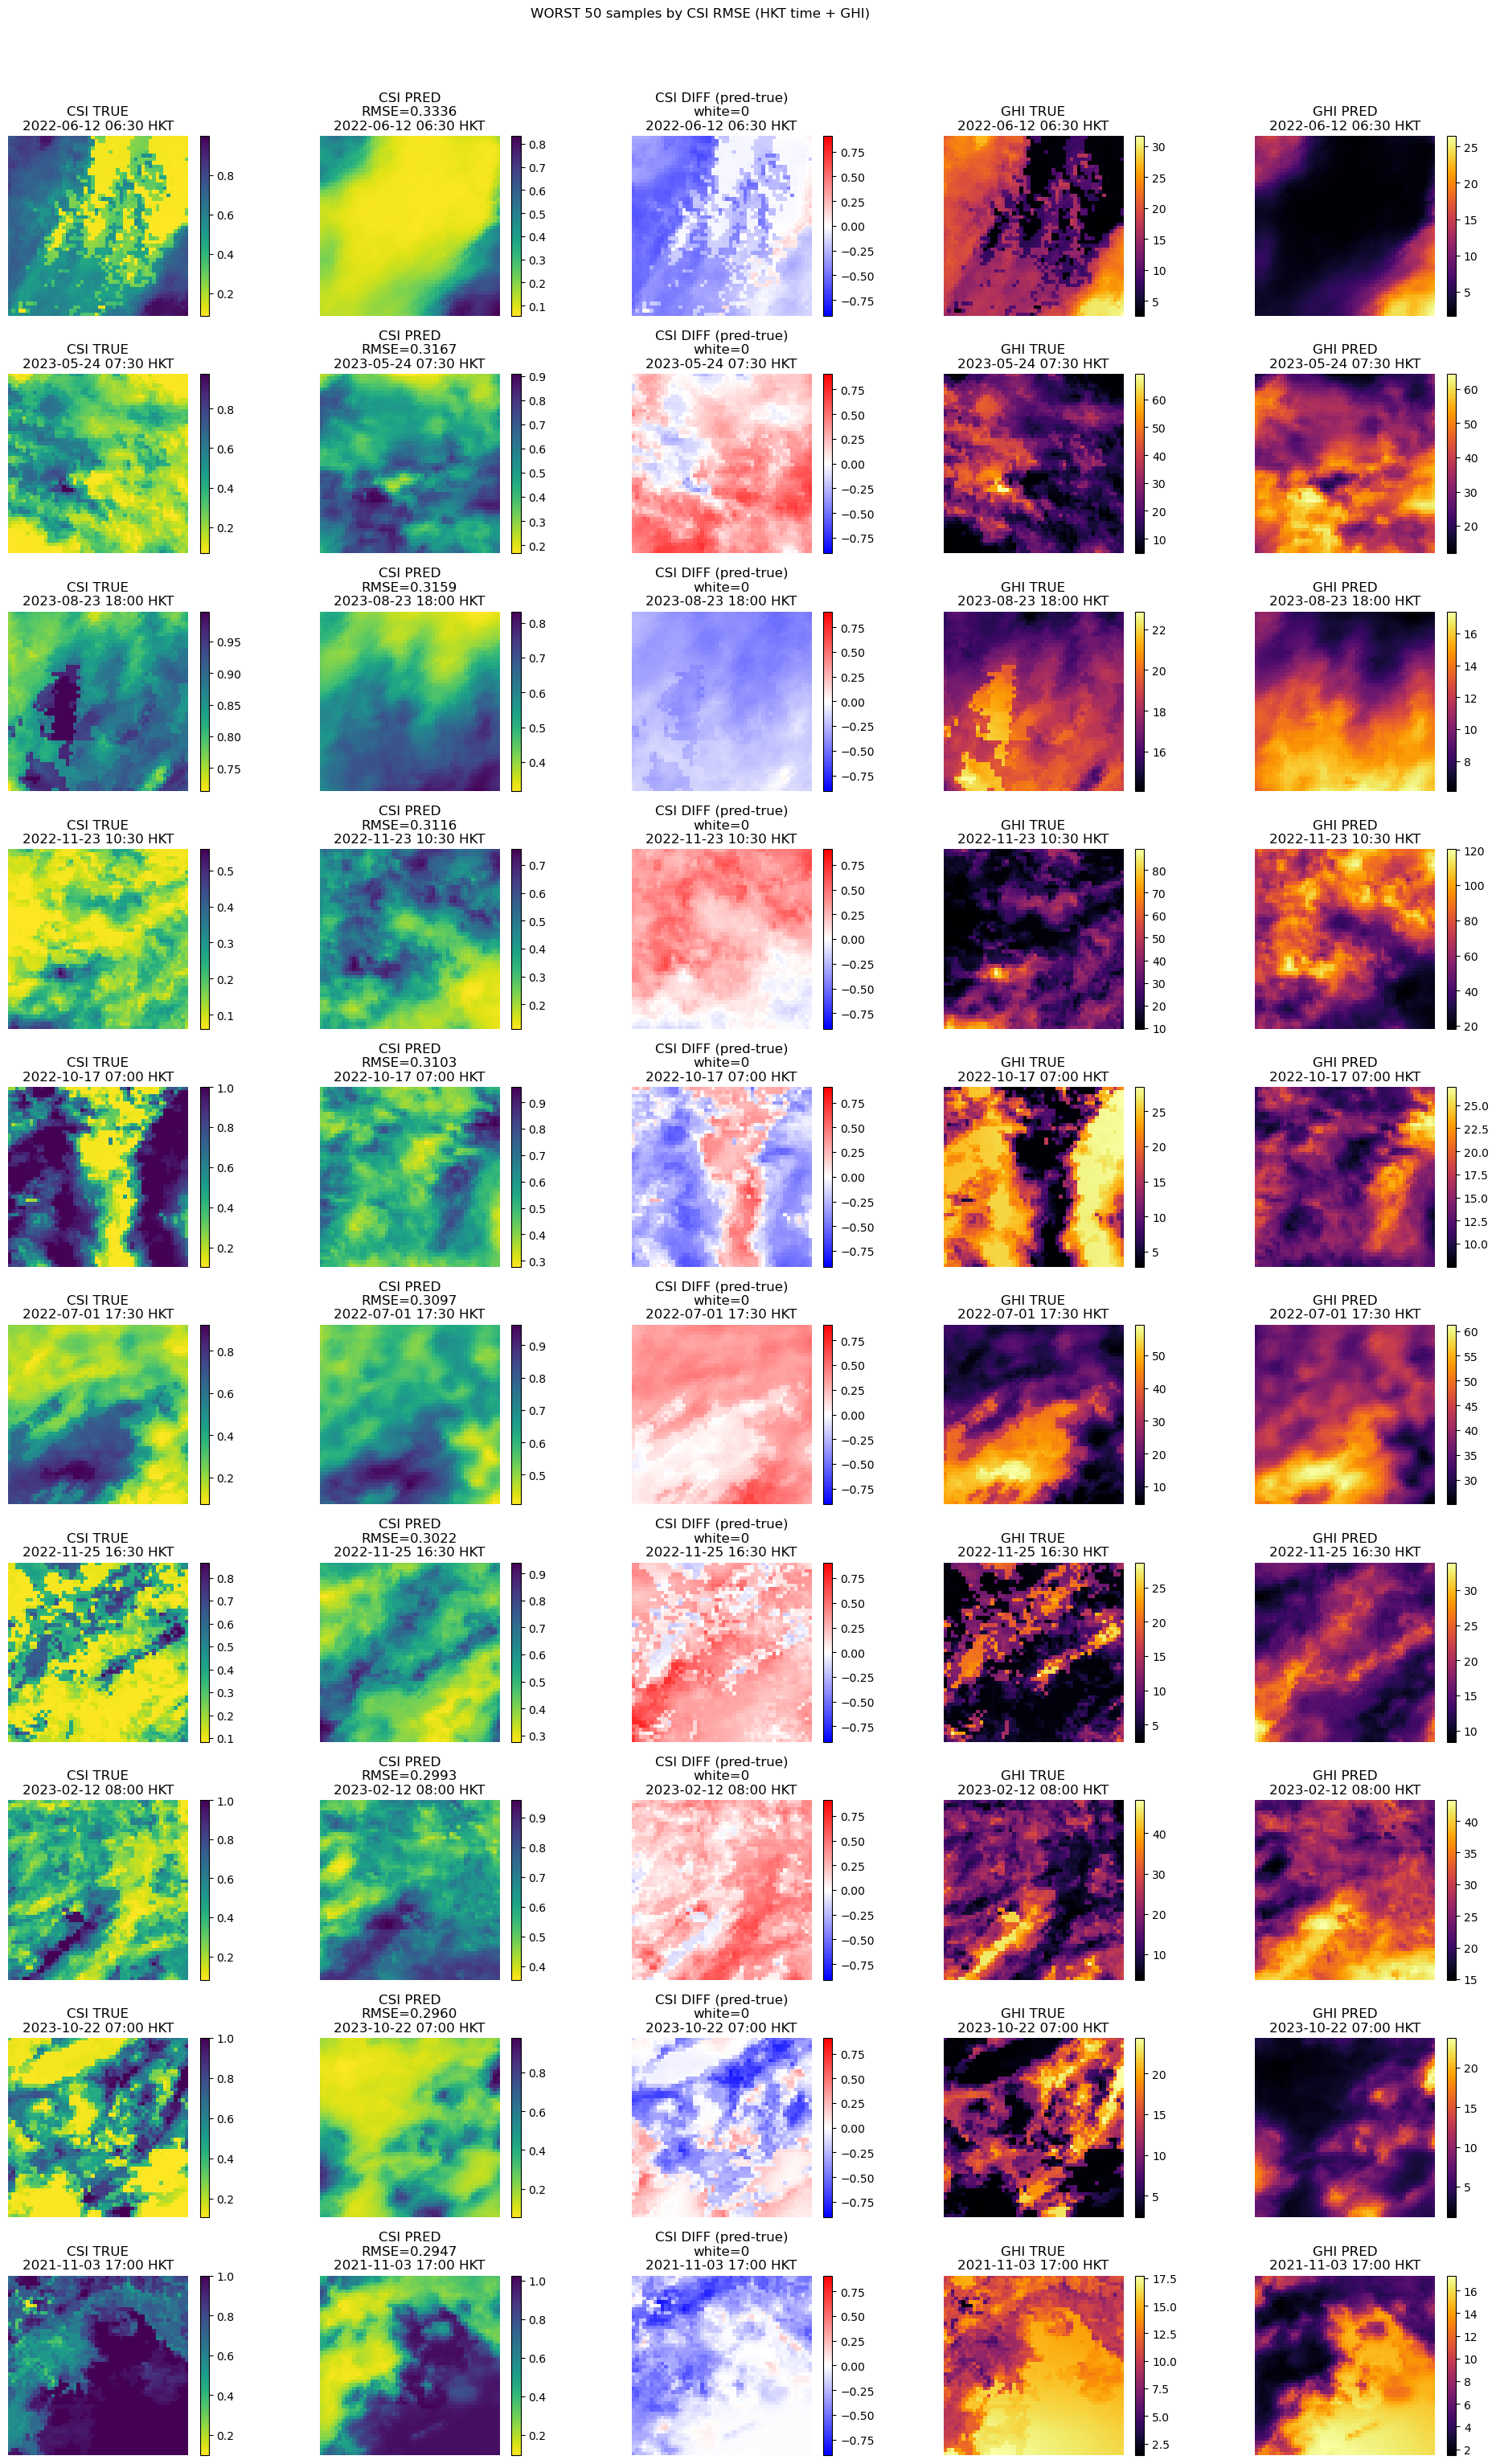

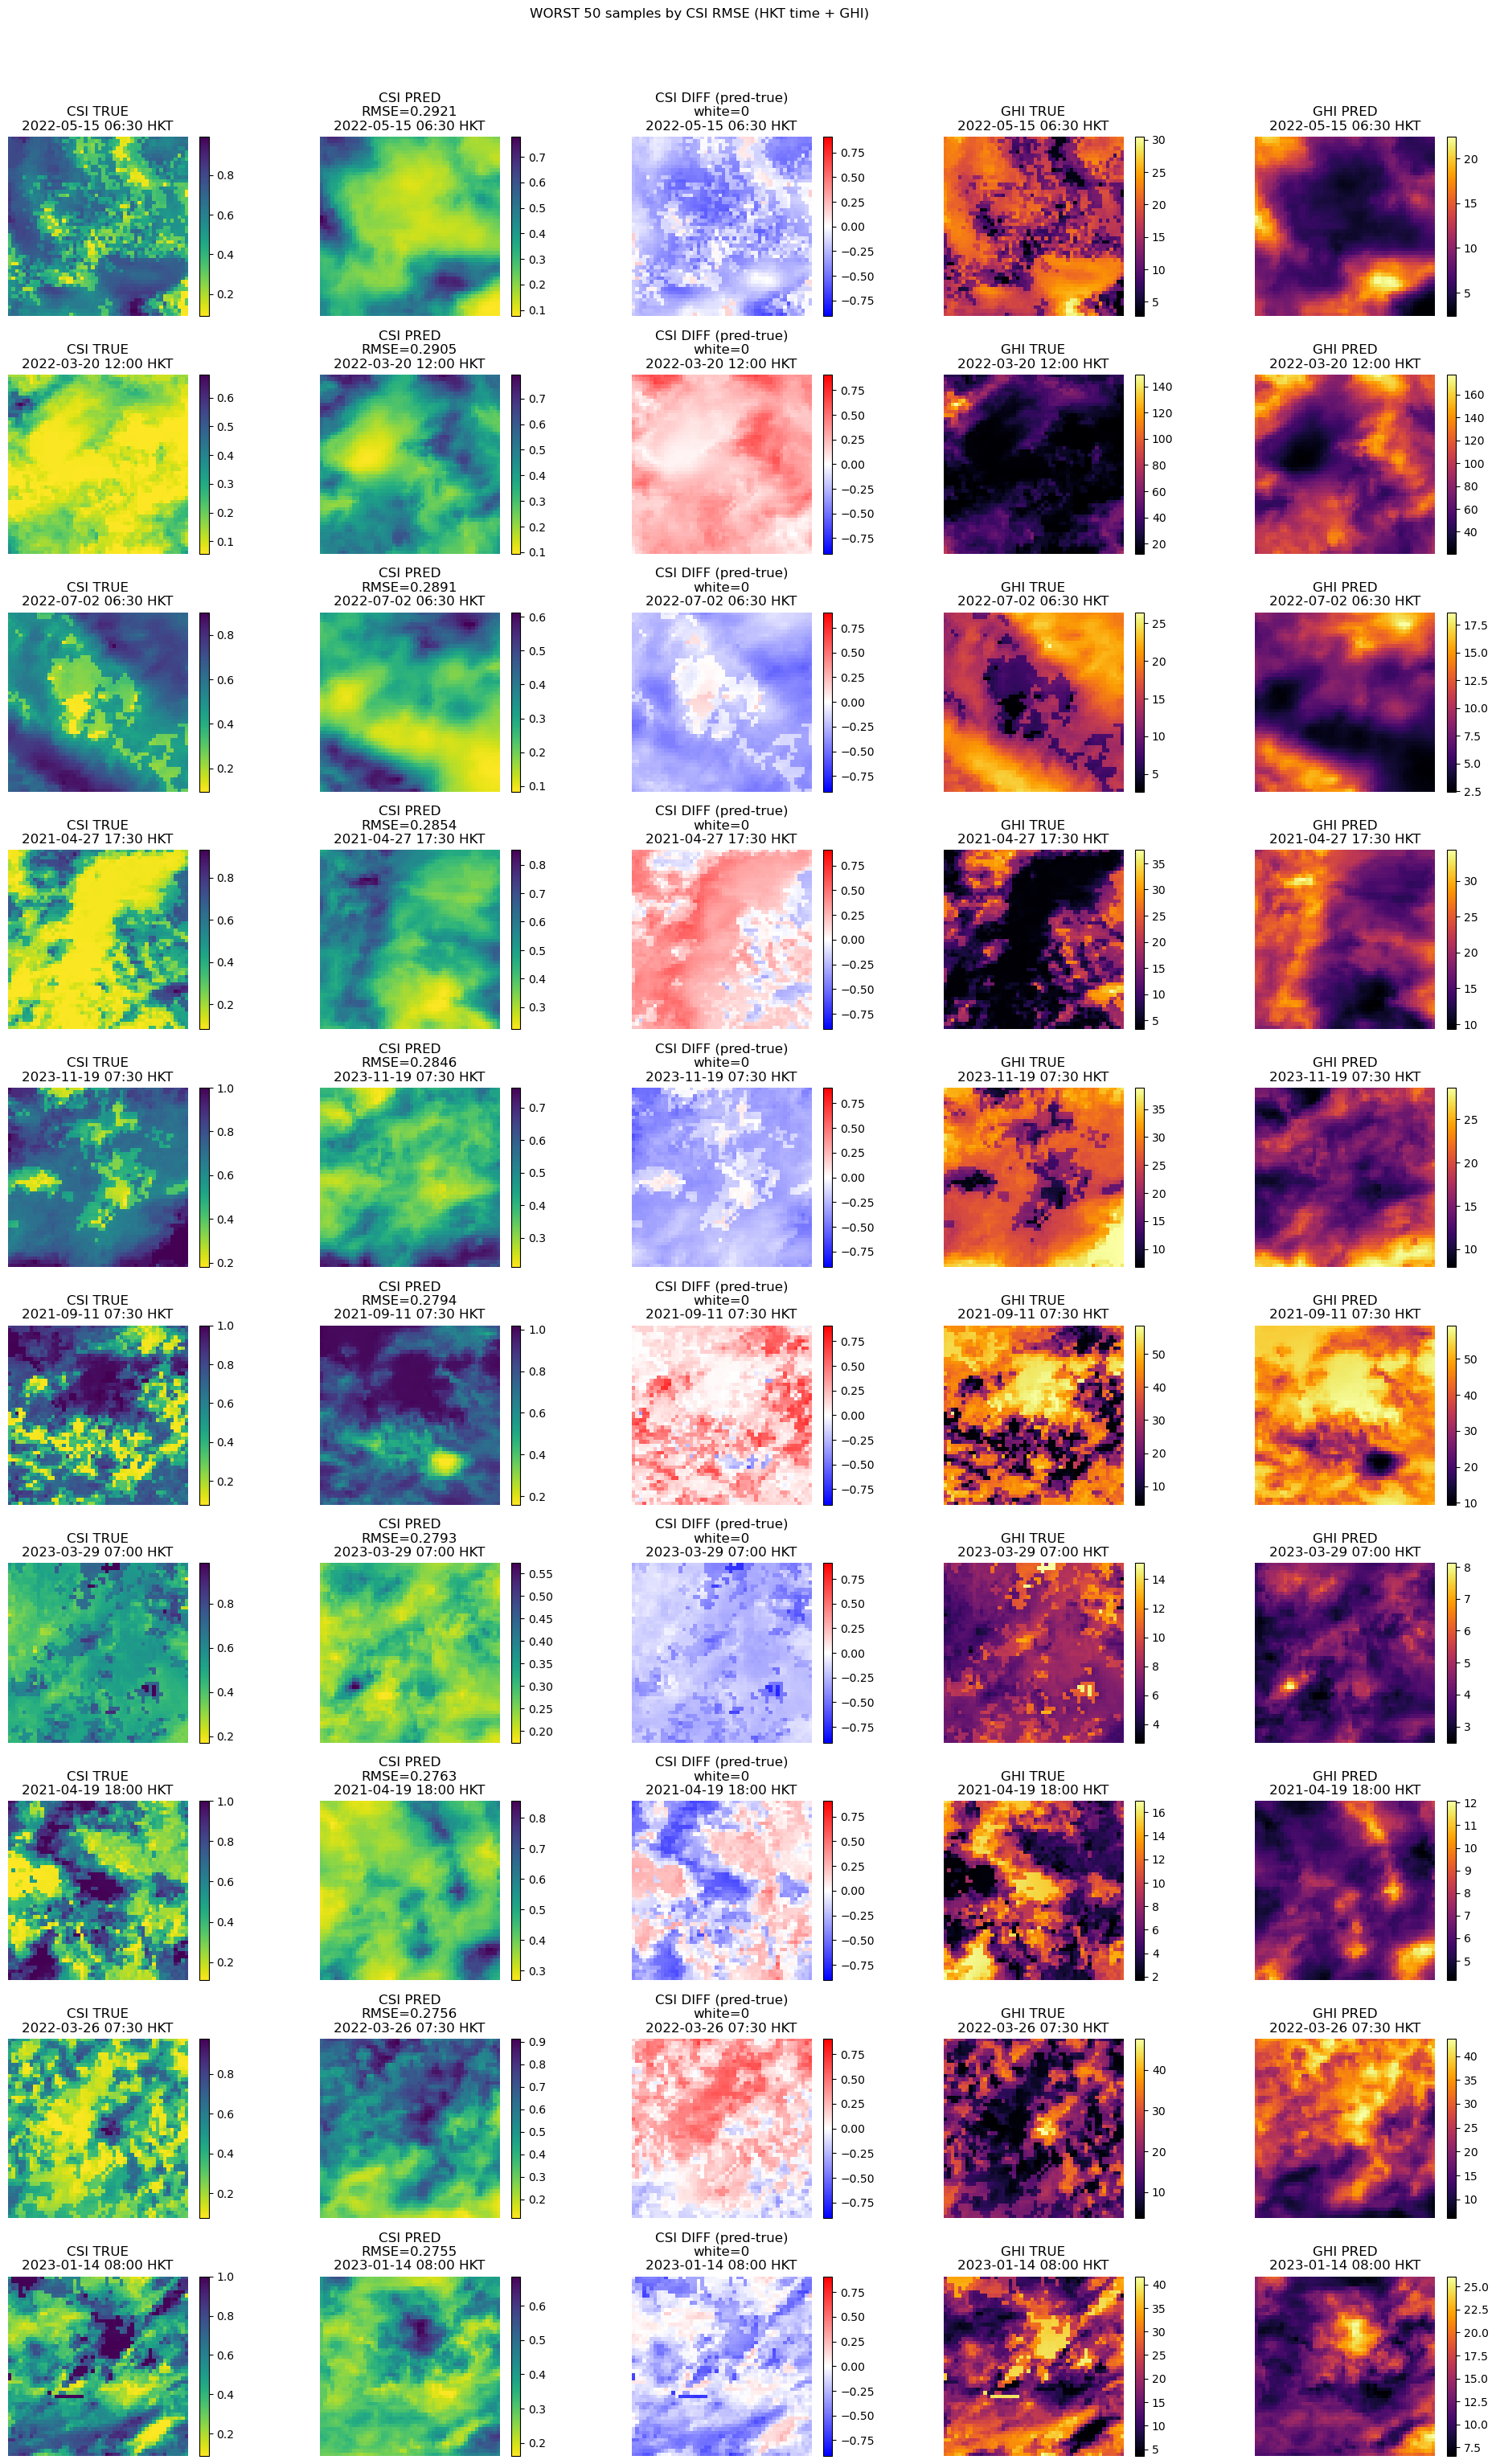

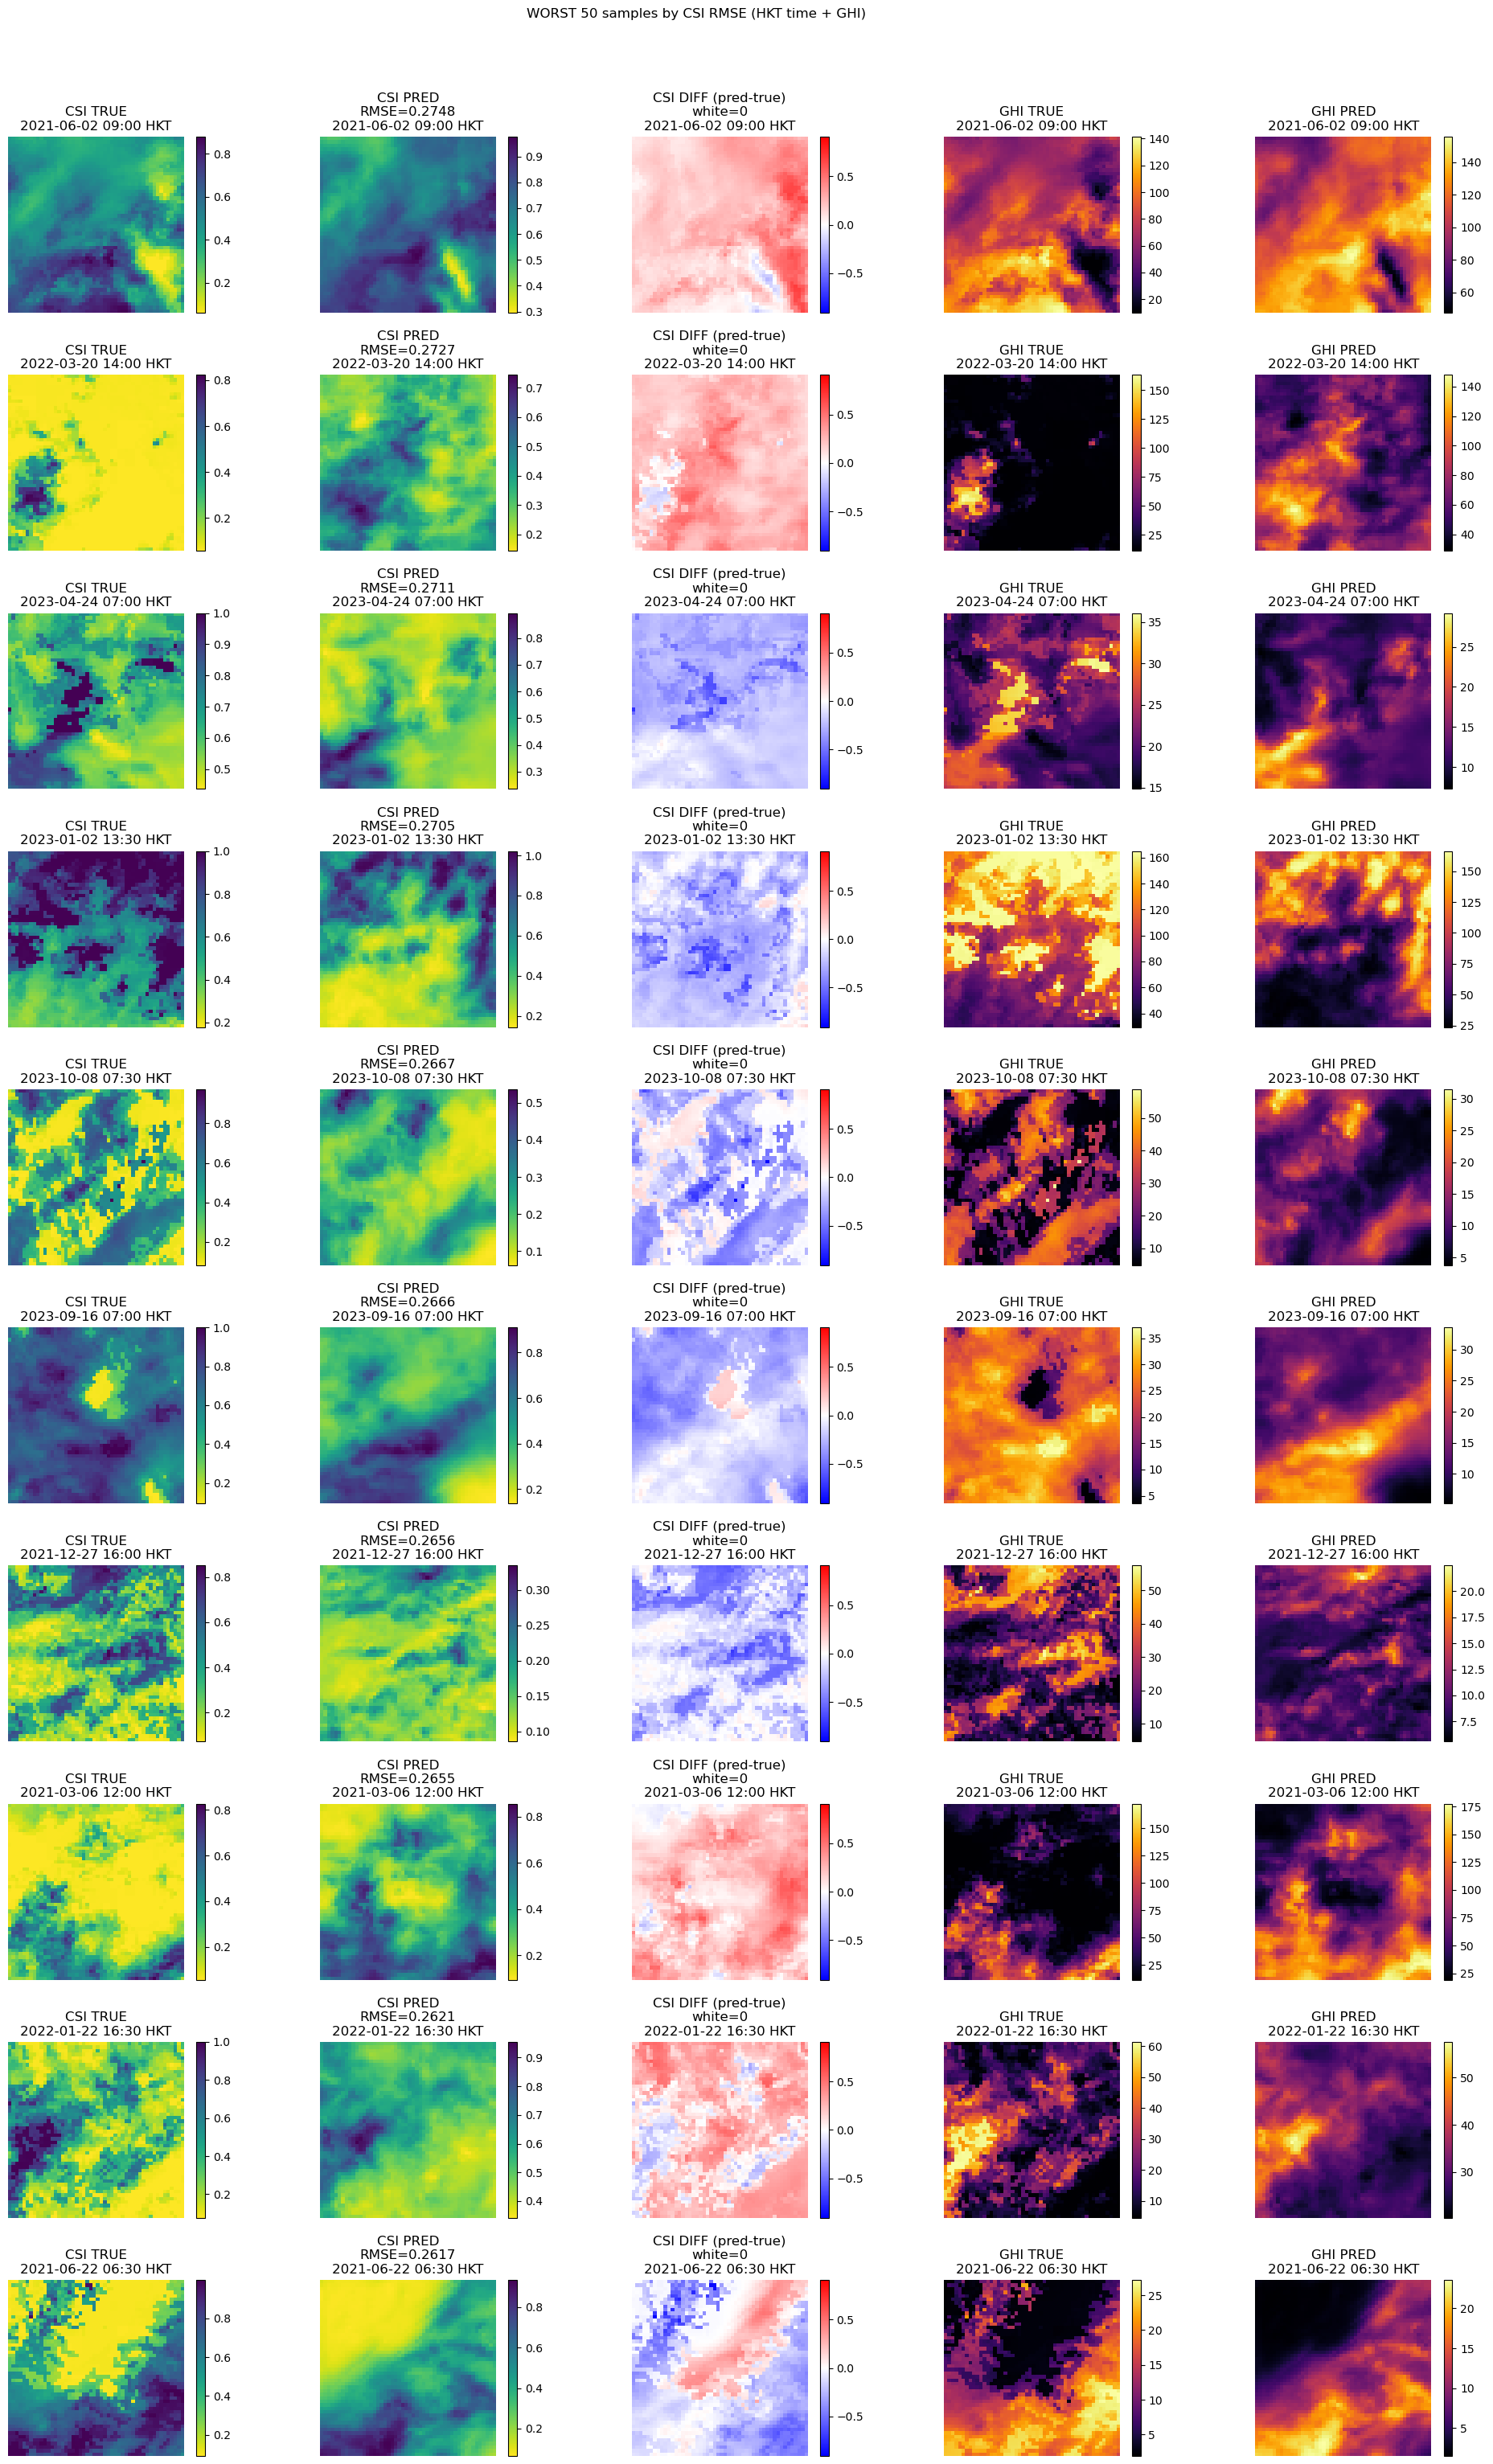

In [38]:
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=50, mode="worst",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)

